# Handling Class Imbalance in Credit Card Fraud Detection

## Table of Contents
1. [Introduction and Problem Description](#1-introduction-and-problem-description)
2. [Data Exploration and Preprocessing](#2-data-exploration-and-preprocessing)
3. [Evaluation Metrics for Imbalanced Classification](#3-evaluation-metrics-for-imbalanced-classification)
4. [Baseline Model (No Imbalance Handling)](#4-baseline-model-no-imbalance-handling)
5. [Data-Level Approaches](#5-data-level-approaches)
   - 5.1 [Random Undersampling](#51-random-undersampling)
   - 5.2 [Random Oversampling](#52-random-oversampling)
   - 5.3 [SMOTE](#53-smote)
   - 5.4 [SMOTE-Tomek](#54-smote-tomek)
   - 5.5 [Comparison of Data-Level Approaches](#55-comparison-of-data-level-approaches)
6. [Algorithm-Level Approaches](#6-algorithm-level-approaches)
   - 6.1 [Cost-Sensitive Learning](#61-cost-sensitive-learning)
   - 6.2 [Threshold Adjustment](#62-threshold-adjustment)
   - 6.3 [Comparison of Algorithm-Level Approaches](#63-comparison-of-algorithm-level-approaches)
7. [Combined Approaches](#7-combined-approaches)
   - 7.1 [SMOTE + Cost-Sensitive Learning](#71-smote--cost-sensitive-learning)
   - 7.2 [SMOTE + Threshold Adjustment](#72-smote--threshold-adjustment)
   - 7.3 [Comparison of Combined Approaches](#73-comparison-of-combined-approaches)
8. [Comprehensive Comparison of All Techniques](#8-comprehensive-comparison-of-all-techniques)
9. [Conclusion and Best Practices](#9-conclusion-and-best-practices)

## 1. Introduction and Problem Description

Credit card fraud detection represents one of the most important applications of machine learning in the financial industry. This problem is inherently challenging due to:

- **Class imbalance**: Fraudulent transactions typically represent only ~0.1-0.2% of all transactions
- **Cost asymmetry**: The cost of false negatives (missed fraud) is much higher than false positives
- **Evolving patterns**: Fraudsters constantly change their strategies
- **Limited data**: Due to privacy concerns, limited features may be available

In this notebook, we'll focus specifically on tackling the class imbalance problem by comparing multiple approaches:

1. **Data-level approaches**: Modify the dataset to balance class distribution
2. **Algorithm-level approaches**: Adjust the learning algorithm to be more sensitive to the minority class
3. **Combined approaches**: Use both data and algorithm techniques together

We'll use a synthetic credit card fraud dataset that mimics real-world patterns while maintaining a realistic imbalance ratio.

Let's start by importing the necessary libraries:

In [15]:
# Standard data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Machine learning tools
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, precision_recall_curve, auc, 
    confusion_matrix, classification_report, 
    roc_curve, average_precision_score
)

# Imbalance handling tools
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
COLORS = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(COLORS))

# Configure pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 2. Data Exploration and Preprocessing

Let's load our synthetic credit card fraud dataset and explore its characteristics:

In [16]:
# Load the dataset
data = pd.read_csv('credit_card_fraud_dataset.csv')

# Display basic information
print(f"Dataset shape: {data.shape}")
print("\nColumn information:")
data.info()

Dataset shape: (100000, 18)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   transaction_id             100000 non-null  object 
 1   transaction_dt             100000 non-null  object 
 2   amount                     100000 non-null  float64
 3   merchant_category          100000 non-null  int64  
 4   transaction_type           100000 non-null  int64  
 5   hour                       100000 non-null  int64  
 6   distance_from_home         100000 non-null  float64
 7   is_foreign                 100000 non-null  int64  
 8   days_since_last_tx         100000 non-null  float64
 9   customer_age               100000 non-null  int64  
 10  previous_fraud_count       100000 non-null  int64  
 11  recent_transactions_count  100000 non-null  int64  
 12  avg_recent_tx_amount       100000 non-

In [17]:
# Check class distribution
fraud_count = data['is_fraud'].sum()
total_count = len(data)
fraud_percentage = fraud_count / total_count * 100

print(f"\nClass distribution:")
print(f"Total transactions: {total_count}")
print(f"Fraudulent transactions: {fraud_count} ({fraud_percentage:.3f}%)")
print(f"Legitimate transactions: {total_count - fraud_count} ({100 - fraud_percentage:.3f}%)")
print("\nClass counts:")
print(data['is_fraud'].value_counts())


Class distribution:
Total transactions: 100000
Fraudulent transactions: 200 (0.200%)
Legitimate transactions: 99800 (99.800%)

Class counts:
is_fraud
0    99800
1      200
Name: count, dtype: int64


Let's visualize the class imbalance:

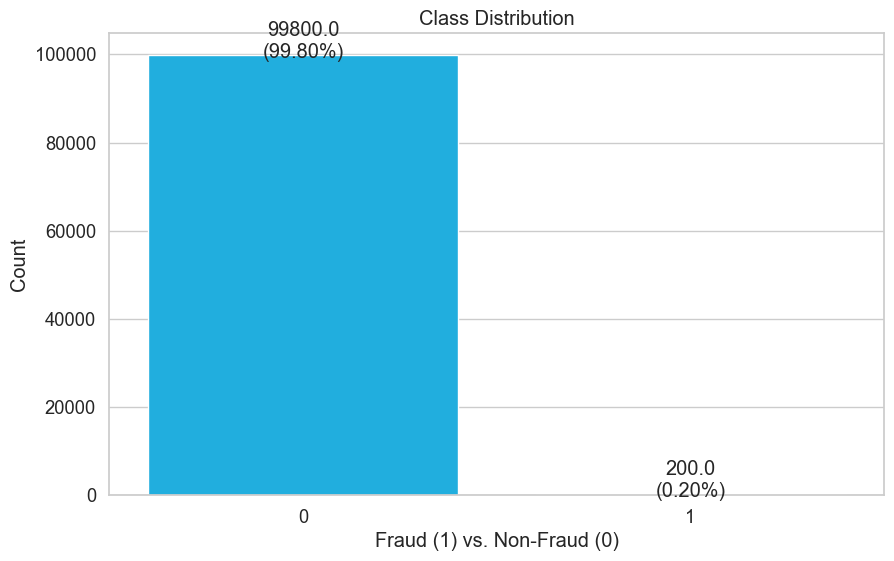

In [18]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='is_fraud', data=data)
plt.title('Class Distribution')
plt.xlabel('Fraud (1) vs. Non-Fraud (0)')
plt.ylabel('Count')

# Add count and percentage labels to bars
total = len(data)
for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total
    ax.annotate(f'{height}\n({percentage:.2f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), textcoords = 'offset points')

plt.show()

Next, let's explore some key features and their relationships with fraud:

C:\Users\solom\AppData\Local\Temp\ipykernel_27044\637195799.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(tx_types)


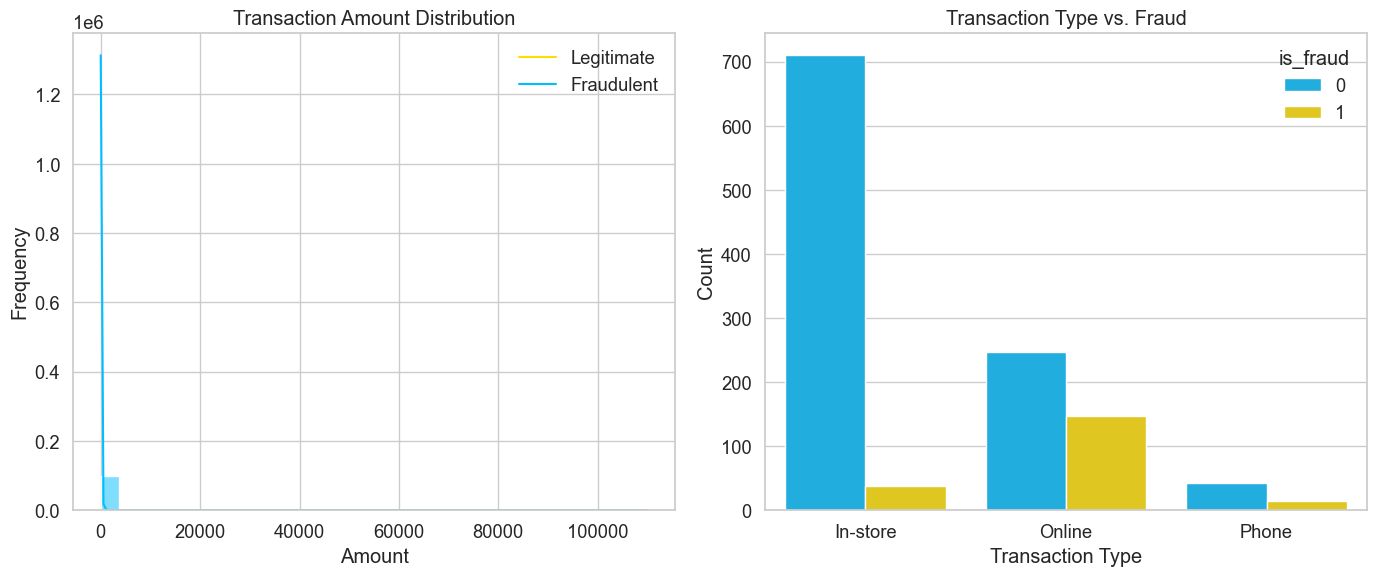

In [19]:
# Distribution of transaction amounts for fraud vs. non-fraud
plt.figure(figsize=(14, 6))
gs = GridSpec(1, 2)

# Transaction amounts by class
ax0 = plt.subplot(gs[0, 0])
sns.histplot(data=data, x='amount', hue='is_fraud', bins=30, kde=True, ax=ax0)
ax0.set_title('Transaction Amount Distribution')
ax0.set_xlabel('Amount')
ax0.set_ylabel('Frequency')
ax0.legend(['Legitimate', 'Fraudulent'])

# Transaction type by class
ax1 = plt.subplot(gs[0, 1])
fraud_only = data[data['is_fraud'] == 1]
non_fraud = data[data['is_fraud'] == 0].sample(n=len(fraud_only)*5)  # Sample for better visualization
combined = pd.concat([fraud_only, non_fraud])

tx_types = ['In-store', 'Online', 'Phone']
sns.countplot(x='transaction_type', hue='is_fraud', data=combined, ax=ax1)
ax1.set_xticklabels(tx_types)
ax1.set_title('Transaction Type vs. Fraud')
ax1.set_xlabel('Transaction Type')
ax1.set_ylabel('Count')

plt.tight_layout()
plt.show()

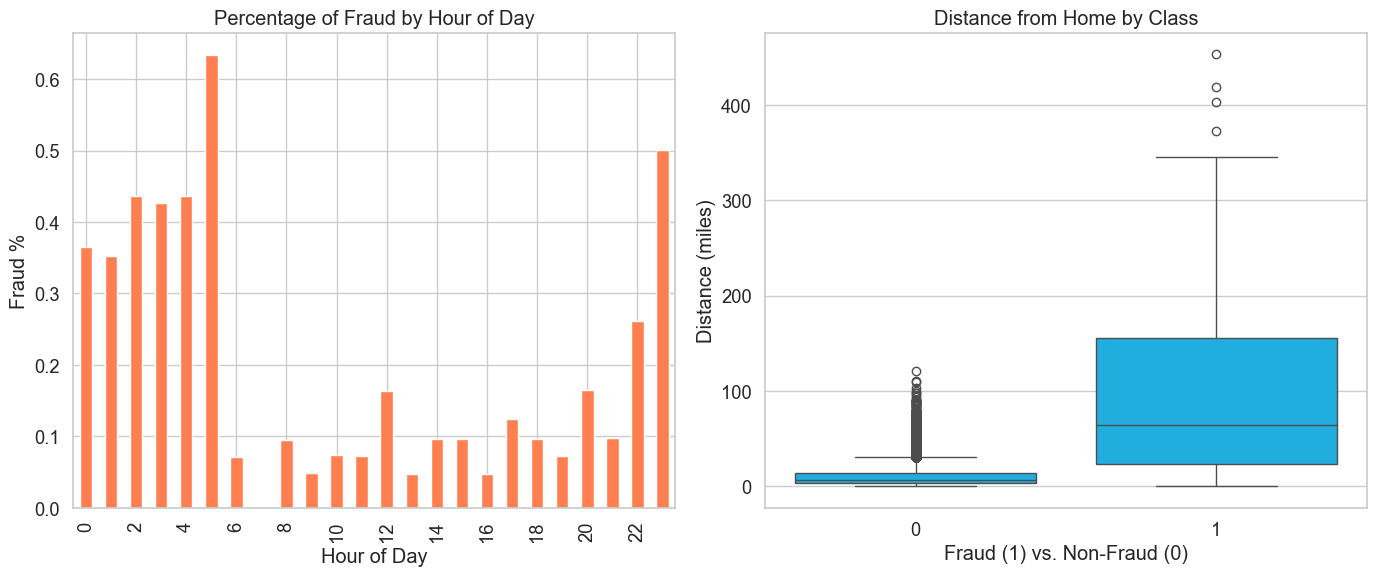

In [20]:
# Hour of day distribution
plt.figure(figsize=(14, 6))
gs = GridSpec(1, 2)

# Hour of day by class
ax0 = plt.subplot(gs[0, 0])
hour_fraud = pd.crosstab(data['hour'], data['is_fraud'])
hour_fraud_pct = hour_fraud.div(hour_fraud.sum(axis=1), axis=0) * 100
hour_fraud_pct[1].plot(kind='bar', ax=ax0, color='coral')
ax0.set_title('Percentage of Fraud by Hour of Day')
ax0.set_xlabel('Hour of Day')
ax0.set_ylabel('Fraud %')
ax0.set_xticks(range(0, 24, 2))

# Distance from home by class
ax1 = plt.subplot(gs[0, 1])
sns.boxplot(x='is_fraud', y='distance_from_home', data=data, ax=ax1)
ax1.set_title('Distance from Home by Class')
ax1.set_xlabel('Fraud (1) vs. Non-Fraud (0)')
ax1.set_ylabel('Distance (miles)')

plt.tight_layout()
plt.show()

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   transaction_id             100000 non-null  object 
 1   transaction_dt             100000 non-null  object 
 2   amount                     100000 non-null  float64
 3   merchant_category          100000 non-null  int64  
 4   transaction_type           100000 non-null  int64  
 5   hour                       100000 non-null  int64  
 6   distance_from_home         100000 non-null  float64
 7   is_foreign                 100000 non-null  int64  
 8   days_since_last_tx         100000 non-null  float64
 9   customer_age               100000 non-null  int64  
 10  previous_fraud_count       100000 non-null  int64  
 11  recent_transactions_count  100000 non-null  int64  
 12  avg_recent_tx_amount       100000 non-null  float64
 13  weekday                    100

In [22]:
data.columns

Index(['transaction_id', 'transaction_dt', 'amount', 'merchant_category',
       'transaction_type', 'hour', 'distance_from_home', 'is_foreign',
       'days_since_last_tx', 'customer_age', 'previous_fraud_count',
       'recent_transactions_count', 'avg_recent_tx_amount', 'weekday', 'month',
       'day', 'is_fraud', 'customer_id'],
      dtype='object')

In [23]:
num = [ 'amount', 'merchant_category',
       'transaction_type', 'hour', 'distance_from_home', 'is_foreign',
       'days_since_last_tx', 'customer_age', 'previous_fraud_count',
       'recent_transactions_count', 'avg_recent_tx_amount', 'weekday', 'month',
       'day', 'is_fraud']

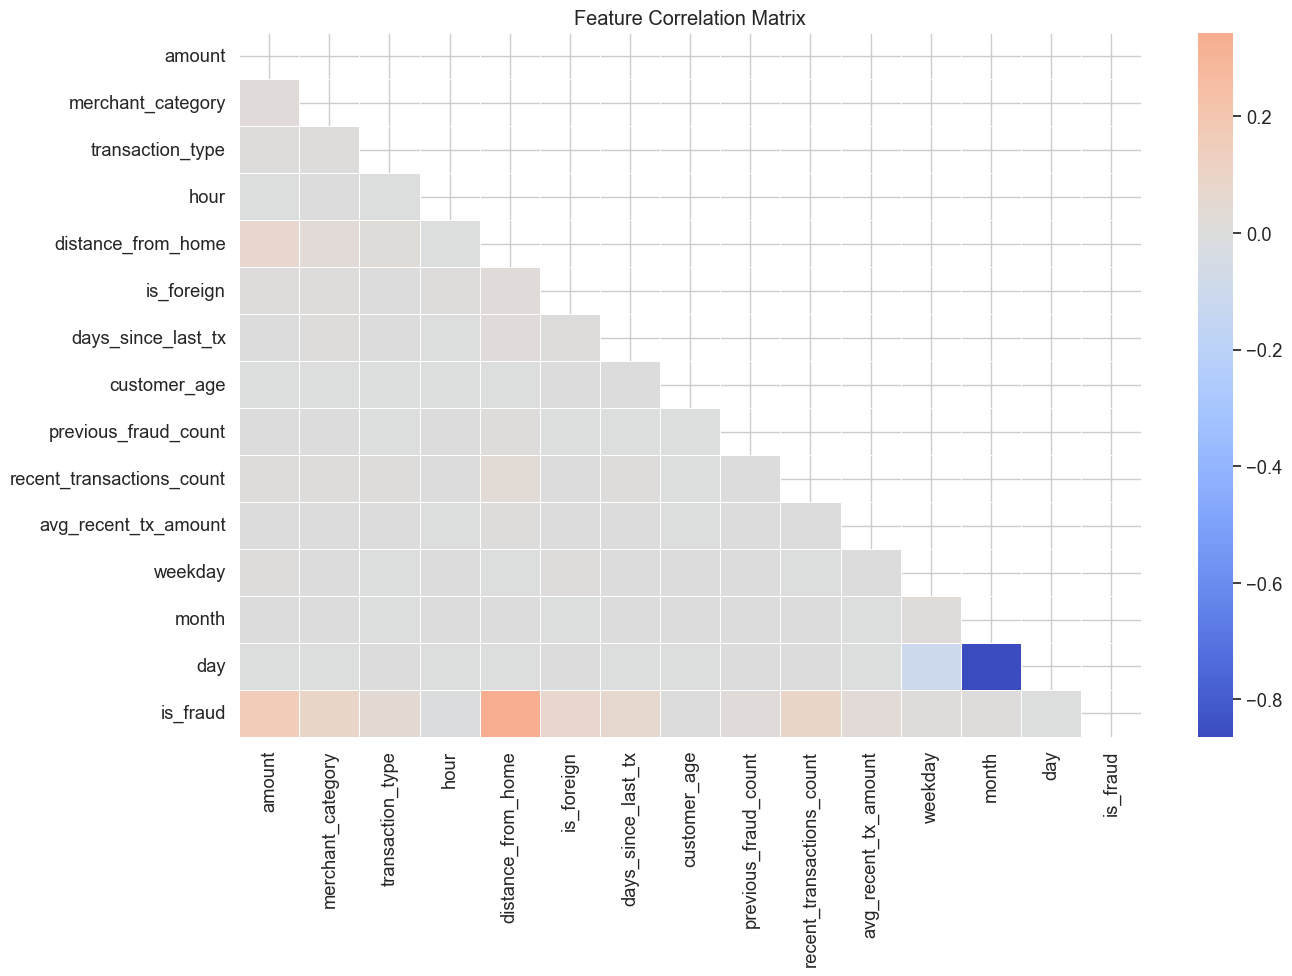

In [24]:
# Correlation matrix for features
plt.figure(figsize=(14, 10))
correlation_matrix = data[num].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

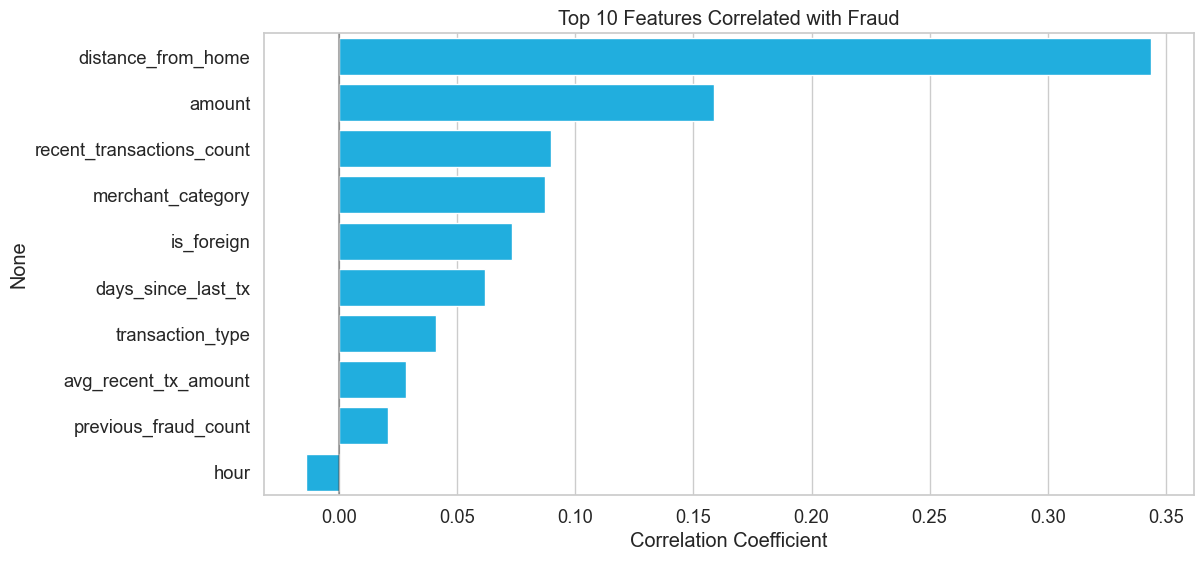

In [25]:
# Top correlations with fraud
plt.figure(figsize=(12, 6))
top_corr = correlation_matrix['is_fraud'].sort_values(ascending=False)
top_corr = top_corr[top_corr.index != 'is_fraud']  # Remove self-correlation
top_corr_abs = top_corr.abs().sort_values(ascending=False)
top_features = top_corr_abs.head(10).index

sns.barplot(x=top_corr[top_features], y=top_features)
plt.title('Top 10 Features Correlated with Fraud')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.show()

Now let's prepare the data for modeling:

In [26]:
# Check for missing values
print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
transaction_id               0
transaction_dt               0
amount                       0
merchant_category            0
transaction_type             0
hour                         0
distance_from_home           0
is_foreign                   0
days_since_last_tx           0
customer_age                 0
previous_fraud_count         0
recent_transactions_count    0
avg_recent_tx_amount         0
weekday                      0
month                        0
day                          0
is_fraud                     0
customer_id                  0
dtype: int64


In [27]:
# Extract features and target
X = data.drop(['is_fraud', 'transaction_id', 'transaction_dt', 'customer_id'], axis=1)
y = data['is_fraud']

# Convert categorical features to one-hot encoding
X = pd.get_dummies(X, columns=['transaction_type'], drop_first=True)

# Split data into training and testing sets (stratified to maintain class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")
print(f"Training set fraud percentage: {y_train.mean()*100:.3f}%")
print(f"Testing set fraud percentage: {y_test.mean()*100:.3f}%")

Training set shape: (80000, 15), Testing set shape: (20000, 15)
Training set fraud percentage: 0.200%
Testing set fraud percentage: 0.200%


In [28]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame for easier handling (keeping original column names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

## 3. Evaluation Metrics for Imbalanced Classification

Choosing appropriate evaluation metrics is crucial for imbalanced datasets. Let's define our evaluation strategy:

In [29]:
def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model"):
    """
    Evaluate model performance with metrics suited for imbalanced classification.
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    y_prob : array-like, optional
        Predicted probabilities for the positive class
    model_name : str, default="Model"
        Name of the model for display
        
    Returns:
    --------
    dict
        Dictionary containing all calculated metrics
    """
    # Basic classification metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Initialize result dictionary
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }
    
    # Compute confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate additional metrics if probabilities are provided
    if y_prob is not None:
        # ROC AUC
        roc_auc = roc_auc_score(y_true, y_prob)
        results['ROC AUC'] = roc_auc
        
        # Precision-Recall AUC
        precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = auc(recall_curve, precision_curve)
        results['PR AUC'] = pr_auc
        
        # Average Precision
        ap = average_precision_score(y_true, y_prob)
        results['Average Precision'] = ap
    
    # Print results
    print(f"\n----- {model_name} Evaluation -----")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    if y_prob is not None:
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"PR AUC: {pr_auc:.4f}")
        print(f"Average Precision: {ap:.4f}")
    
    print("\nConfusion Matrix:")
    cm_display = np.array([[tn, fp], [fn, tp]])
    print(cm_display)
    
    return results

def plot_model_comparison(results_df, metrics=None):
    """
    Plot comparison of multiple models across selected metrics.
    
    Parameters:
    -----------
    results_df : pandas.DataFrame
        DataFrame containing metrics for multiple models
    metrics : list, optional
        List of metrics to plot. If None, use default set of metrics.
    """
    if metrics is None:
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    
    # Create figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.flatten()
    
    # Plot each metric
    for i, metric in enumerate(metrics):
        ax = axs[i]
        sns.barplot(x='Model', y=metric, data=results_df, ax=ax)
        ax.set_title(f'Comparison of {metric}')
        # Set x-tick labels with rotation for better readability
        ticks_pos = ax.get_xticks()
        tick_labels = [item.get_text() for item in ax.get_xticklabels()]
        ax.set_xticks(ticks_pos)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_roc_curves(models_data):
    """
    Plot ROC curves for multiple models.
    
    Parameters:
    -----------
    models_data : list of tuples
        List of (model_name, y_true, y_pred_proba) tuples
    """
    plt.figure(figsize=(10, 8))
    
    for model_name, y_true, y_prob in models_data:
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)
        
        # Plot ROC curve
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')
    
    # Plot random classifier line
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_pr_curves(models_data):
    """
    Plot Precision-Recall curves for multiple models.
    
    Parameters:
    -----------
    models_data : list of tuples
        List of (model_name, y_true, y_pred_proba) tuples
    """
    plt.figure(figsize=(10, 8))
    
    for model_name, y_true, y_prob in models_data:
        # Calculate Precision-Recall curve
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = auc(recall, precision)
        ap = average_precision_score(y_true, y_prob)
        
        # Plot PR curve
        plt.plot(recall, precision, label=f'{model_name} (AP = {ap:.4f})')
    
    # Plot baseline
    no_skill = np.sum(y_test) / len(y_test)
    plt.plot([0, 1], [no_skill, no_skill], 'k--', label=f'Baseline ({no_skill:.4f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves Comparison')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

## 4. Baseline Model (No Imbalance Handling)

First, let's establish a baseline using logistic regression without any class imbalance handling:

In [30]:
# Initialize and train a logistic regression model without any adjustments
baseline_model = LogisticRegression(random_state=RANDOM_STATE)
baseline_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_prob_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the baseline model
baseline_results = evaluate_model(y_test, y_pred_baseline, y_prob_baseline, "Baseline (No Adjustment)")

# Initialize results DataFrame
all_results = pd.DataFrame([baseline_results])


----- Baseline (No Adjustment) Evaluation -----
Accuracy: 0.9996
Precision: 0.9429
Recall: 0.8250
F1 Score: 0.8800
ROC AUC: 0.9979
PR AUC: 0.8635
Average Precision: 0.8640

Confusion Matrix:
[[19958     2]
 [    7    33]]


In [31]:
all_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Average Precision
0,Baseline (No Adjustment),0.99955,0.942857,0.825,0.88,0.997866,0.863523,0.863965


In [32]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19960
           1       0.94      0.82      0.88        40

    accuracy                           1.00     20000
   macro avg       0.97      0.91      0.94     20000
weighted avg       1.00      1.00      1.00     20000



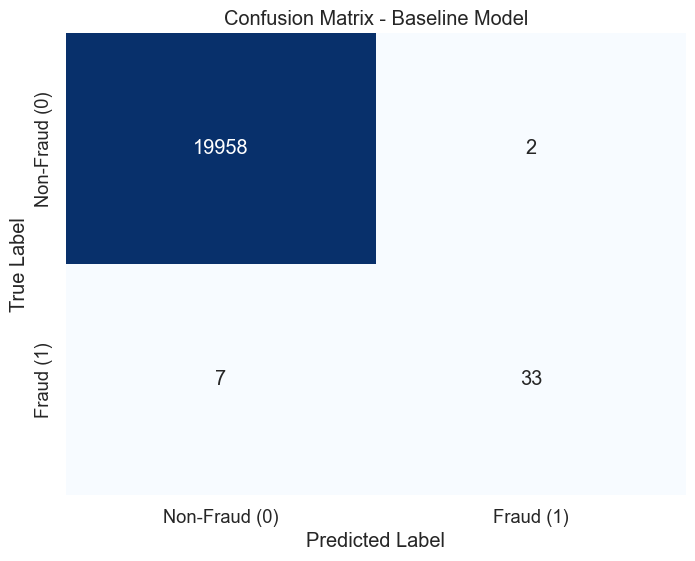

In [33]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Baseline Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.yticks([0.5, 1.5], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

As we can see, the baseline model performs poorly on the fraud class. This is expected due to the extreme class imbalance in the dataset. Now, let's explore various approaches to address this imbalance.

## 5. Data-Level Approaches

### 5.1 Random Undersampling

Random undersampling reduces the majority class by randomly removing examples until a more balanced ratio is achieved.

In [34]:
# Apply random undersampling
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_STATE)  # 1:2 ratio
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {X_train_scaled.shape}")
print(f"Undersampled training set shape: {X_train_rus.shape}")
print(f"\nOriginal class distribution: {pd.Series(y_train).value_counts()}")
print(f"\nUndersampled class distribution: {pd.Series(y_train_rus).value_counts()}")

Original training set shape: (80000, 15)
Undersampled training set shape: (480, 15)

Original class distribution: is_fraud
0    79840
1      160
Name: count, dtype: int64

Undersampled class distribution: is_fraud
0    320
1    160
Name: count, dtype: int64


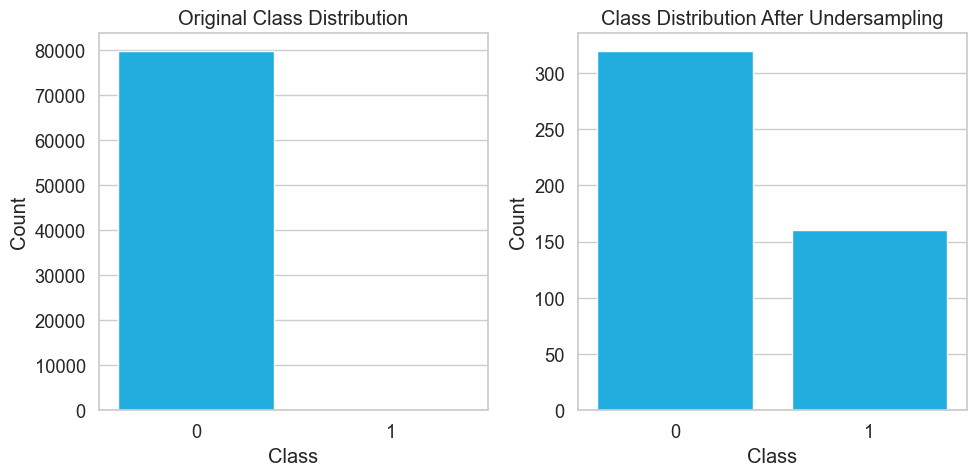

In [35]:
# Visualize class distribution after undersampling
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Original Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_rus)
plt.title('Class Distribution After Undersampling')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [36]:
# Train logistic regression on undersampled data
rus_model = LogisticRegression(random_state=RANDOM_STATE)
rus_model.fit(X_train_rus, y_train_rus)

# Make predictions
y_pred_rus = rus_model.predict(X_test_scaled)
y_prob_rus = rus_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the undersampling approach
rus_results = evaluate_model(y_test, y_pred_rus, y_prob_rus, "Random Undersampling")

# Add results to DataFrame
all_results = pd.concat([all_results, pd.DataFrame([rus_results])], ignore_index=True)


----- Random Undersampling Evaluation -----
Accuracy: 0.9803
Precision: 0.0903
Recall: 0.9750
F1 Score: 0.1653
ROC AUC: 0.9985
PR AUC: 0.8649
Average Precision: 0.8655

Confusion Matrix:
[[19567   393]
 [    1    39]]


### 5.2 Random Oversampling

Random oversampling increases the minority class by duplicating existing examples until a more balanced ratio is achieved.

In [37]:
# Apply random oversampling
ros = RandomOverSampler(sampling_strategy=0.5, random_state=RANDOM_STATE)  # 1:2 ratio
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {X_train_scaled.shape}")
print(f"Oversampled training set shape: {X_train_ros.shape}")
print(f"Original class distribution: {pd.Series(y_train).value_counts()}")
print(f"Oversampled class distribution: {pd.Series(y_train_ros).value_counts()}")

Original training set shape: (80000, 15)
Oversampled training set shape: (119760, 15)
Original class distribution: is_fraud
0    79840
1      160
Name: count, dtype: int64
Oversampled class distribution: is_fraud
0    79840
1    39920
Name: count, dtype: int64


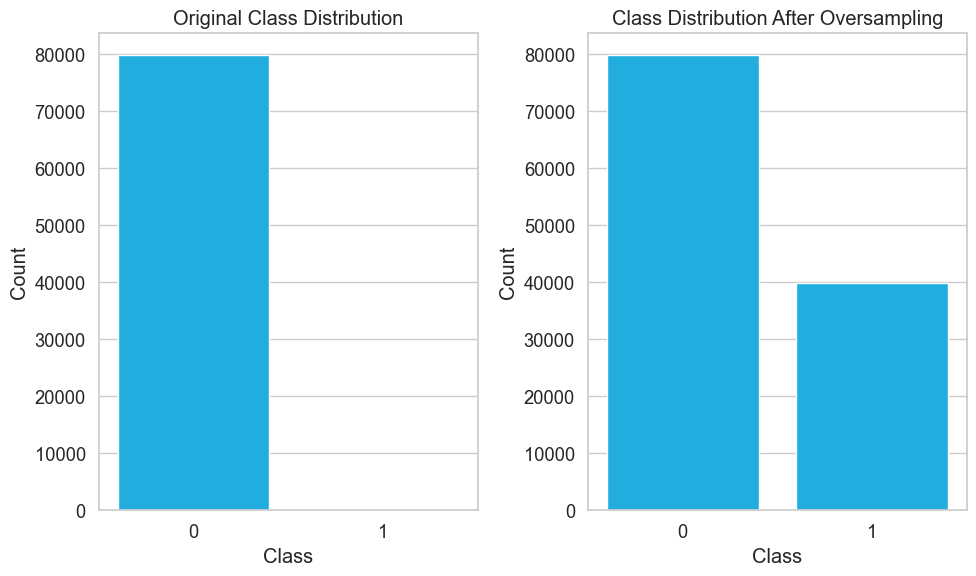

In [38]:
# Visualize class distribution after oversampling
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Original Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_ros)
plt.title('Class Distribution After Oversampling')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [39]:
# Train logistic regression on oversampled data
ros_model = LogisticRegression(random_state=RANDOM_STATE)
ros_model.fit(X_train_ros, y_train_ros)

# Make predictions
y_pred_ros = ros_model.predict(X_test_scaled)
y_prob_ros = ros_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the oversampling approach
ros_results = evaluate_model(y_test, y_pred_ros, y_prob_ros, "Random Oversampling")

# Add results to DataFrame
all_results = pd.concat([all_results, pd.DataFrame([ros_results])], ignore_index=True)


----- Random Oversampling Evaluation -----
Accuracy: 0.9821
Precision: 0.0987
Recall: 0.9750
F1 Score: 0.1793
ROC AUC: 0.9987
PR AUC: 0.8573
Average Precision: 0.8580

Confusion Matrix:
[[19604   356]
 [    1    39]]


### 5.3 SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic examples for the minority class by interpolating between existing examples.

In [40]:
# Apply SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {X_train_scaled.shape}")
print(f"SMOTE training set shape: {X_train_smote.shape}")
print(f"Original class distribution: {pd.Series(y_train).value_counts()}")
print(f"SMOTE class distribution: {pd.Series(y_train_smote).value_counts()}")

Original training set shape: (80000, 15)
SMOTE training set shape: (119760, 15)
Original class distribution: is_fraud
0    79840
1      160
Name: count, dtype: int64
SMOTE class distribution: is_fraud
0    79840
1    39920
Name: count, dtype: int64


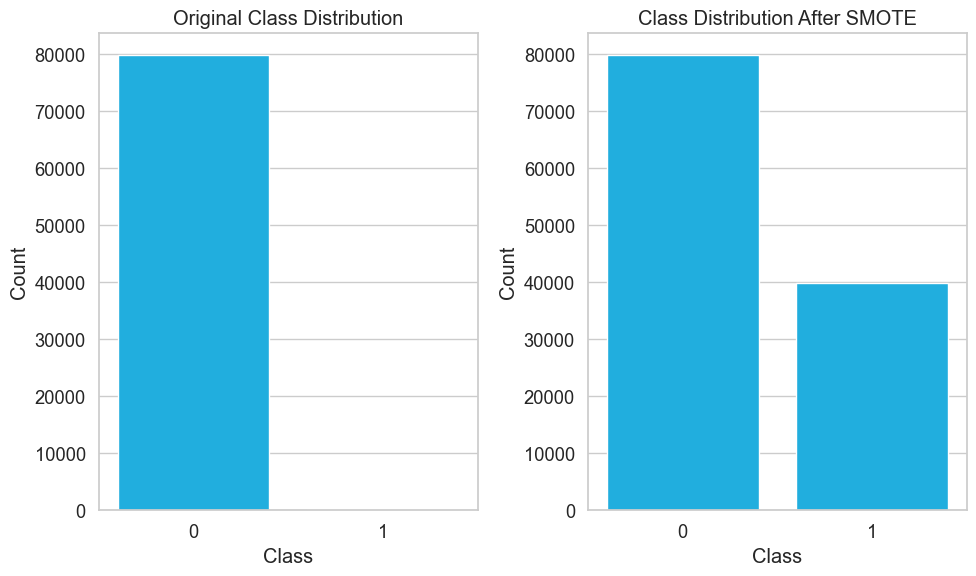

In [41]:
# Visualize class distribution after SMOTE
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Original Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

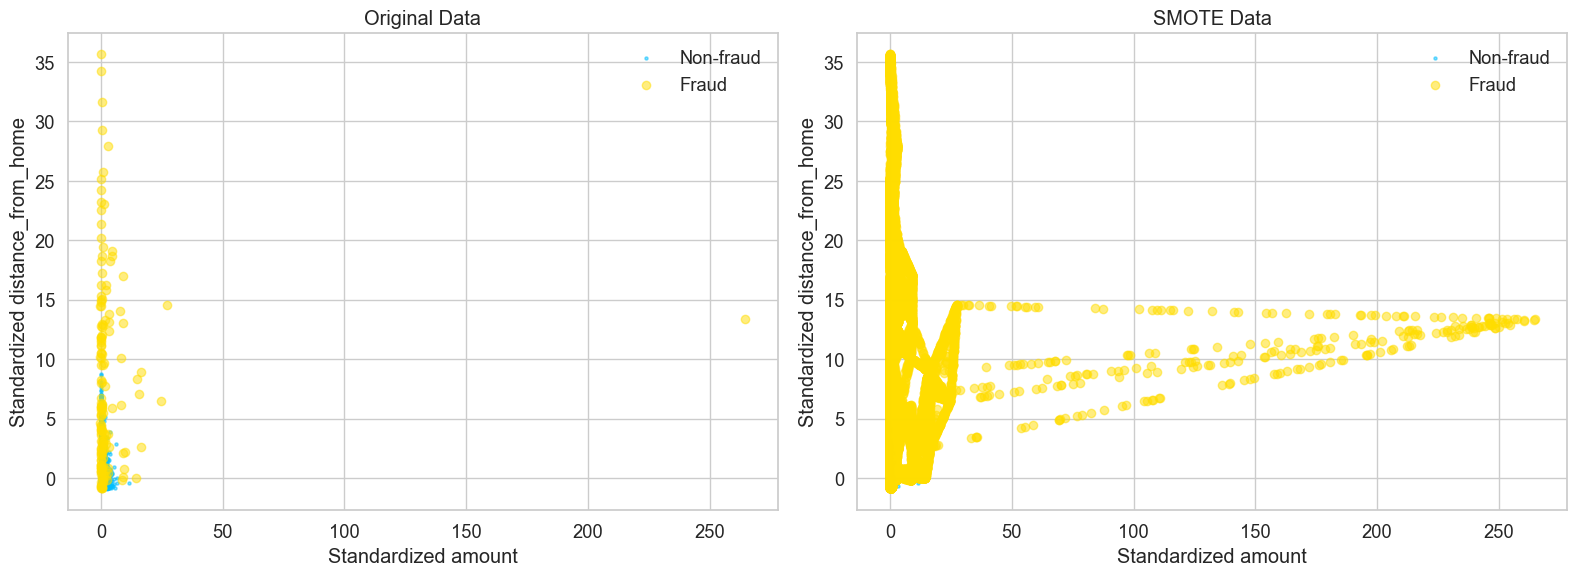

In [42]:
# Visualize feature distribution before and after SMOTE (for 2 selected features)
plt.figure(figsize=(16, 6))

# Select two informative features for visualization
feature1 = 'amount'
feature2 = 'distance_from_home'
feature_idx1 = X_train.columns.get_loc(feature1)
feature_idx2 = X_train.columns.get_loc(feature2)

# Convert to numpy arrays for easier indexing
X_train_np = X_train_scaled.values
y_train_np = np.array(y_train)
X_smote_np = X_train_smote.values
y_smote_np = np.array(y_train_smote)

# Original data
plt.subplot(1, 2, 1)
plt.scatter(X_train_np[y_train_np==0, feature_idx1], 
            X_train_np[y_train_np==0, feature_idx2], 
            label='Non-fraud', alpha=0.5, s=5)
plt.scatter(X_train_np[y_train_np==1, feature_idx1], 
            X_train_np[y_train_np==1, feature_idx2], 
            label='Fraud', alpha=0.5)
plt.title('Original Data')
plt.xlabel(f'Standardized {feature1}')
plt.ylabel(f'Standardized {feature2}')
plt.legend()

# SMOTE data
plt.subplot(1, 2, 2)
# Subsample non-fraud for visibility
non_fraud_indices = np.where(y_smote_np == 0)[0]
fraud_indices = np.where(y_smote_np == 1)[0]

# Subsample non-fraud for visibility
sample_size = min(len(non_fraud_indices), 1000)
np.random.seed(RANDOM_STATE)
nonfraud_sample = np.random.choice(non_fraud_indices, sample_size, replace=False)

plt.scatter(X_smote_np[nonfraud_sample, feature_idx1], 
            X_smote_np[nonfraud_sample, feature_idx2], 
            label='Non-fraud', alpha=0.5, s=5)
plt.scatter(X_smote_np[fraud_indices, feature_idx1], 
            X_smote_np[fraud_indices, feature_idx2], 
            label='Fraud', alpha=0.5)
plt.title('SMOTE Data')
plt.xlabel(f'Standardized {feature1}')
plt.ylabel(f'Standardized {feature2}')
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
# Train logistic regression on SMOTE data
smote_model = LogisticRegression(random_state=RANDOM_STATE)
smote_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_smote = smote_model.predict(X_test_scaled)
y_prob_smote = smote_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the SMOTE approach
smote_results = evaluate_model(y_test, y_pred_smote, y_prob_smote, "SMOTE")

# Add results to DataFrame
all_results = pd.concat([all_results, pd.DataFrame([smote_results])], ignore_index=True)


----- SMOTE Evaluation -----
Accuracy: 0.9832
Precision: 0.1067
Recall: 1.0000
F1 Score: 0.1928
ROC AUC: 0.9984
PR AUC: 0.8592
Average Precision: 0.8598

Confusion Matrix:
[[19625   335]
 [    0    40]]


### 5.4 SMOTE-Tomek

SMOTE-Tomek is a hybrid approach that first applies SMOTE to oversample the minority class, then uses Tomek links to remove examples that might contribute to overfitting.

In [44]:
# Apply SMOTE-Tomek
smote_tomek = SMOTETomek(sampling_strategy=0.5, random_state=RANDOM_STATE)
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {X_train_scaled.shape}")
print(f"SMOTE-Tomek training set shape: {X_train_smote_tomek.shape}")
print(f"Original class distribution: {pd.Series(y_train).value_counts()}")
print(f"SMOTE-Tomek class distribution: {pd.Series(y_train_smote_tomek).value_counts()}")

Original training set shape: (80000, 15)
SMOTE-Tomek training set shape: (119760, 15)
Original class distribution: is_fraud
0    79840
1      160
Name: count, dtype: int64
SMOTE-Tomek class distribution: is_fraud
0    79840
1    39920
Name: count, dtype: int64


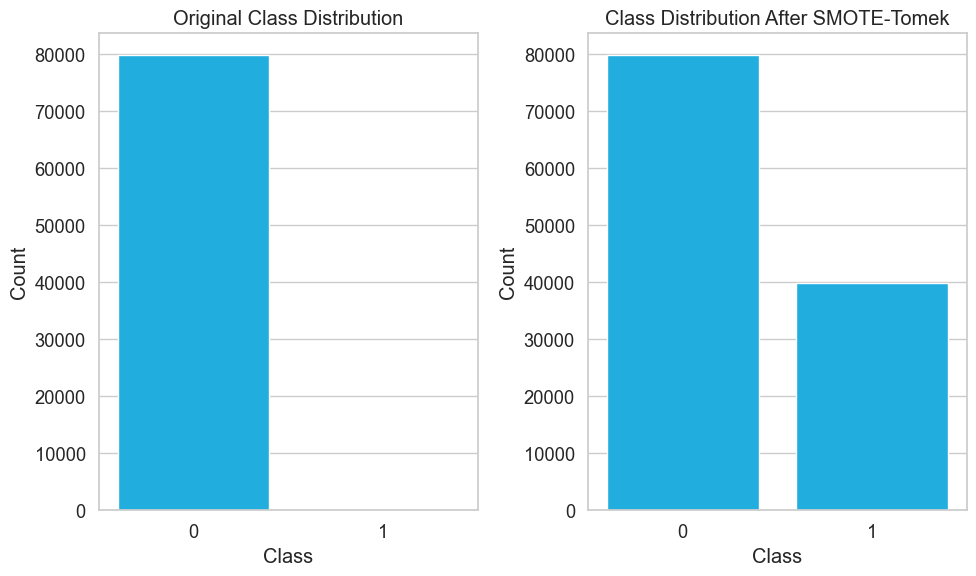

In [45]:
# Visualize class distribution after SMOTE-Tomek
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Original Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote_tomek)
plt.title('Class Distribution After SMOTE-Tomek')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [46]:
# Train logistic regression on SMOTE-Tomek data
smote_tomek_model = LogisticRegression(random_state=RANDOM_STATE)
smote_tomek_model.fit(X_train_smote_tomek, y_train_smote_tomek)

# Make predictions
y_pred_smote_tomek = smote_tomek_model.predict(X_test_scaled)
y_prob_smote_tomek = smote_tomek_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the SMOTE-Tomek approach
smote_tomek_results = evaluate_model(y_test, y_pred_smote_tomek, y_prob_smote_tomek, "SMOTE-Tomek")

# Add results to DataFrame
all_results = pd.concat([all_results, pd.DataFrame([smote_tomek_results])], ignore_index=True)


----- SMOTE-Tomek Evaluation -----
Accuracy: 0.9832
Precision: 0.1067
Recall: 1.0000
F1 Score: 0.1928
ROC AUC: 0.9984
PR AUC: 0.8592
Average Precision: 0.8598

Confusion Matrix:
[[19625   335]
 [    0    40]]


### 5.5 Comparison of Data-Level Approaches

Let's compare the performance of all data-level approaches:

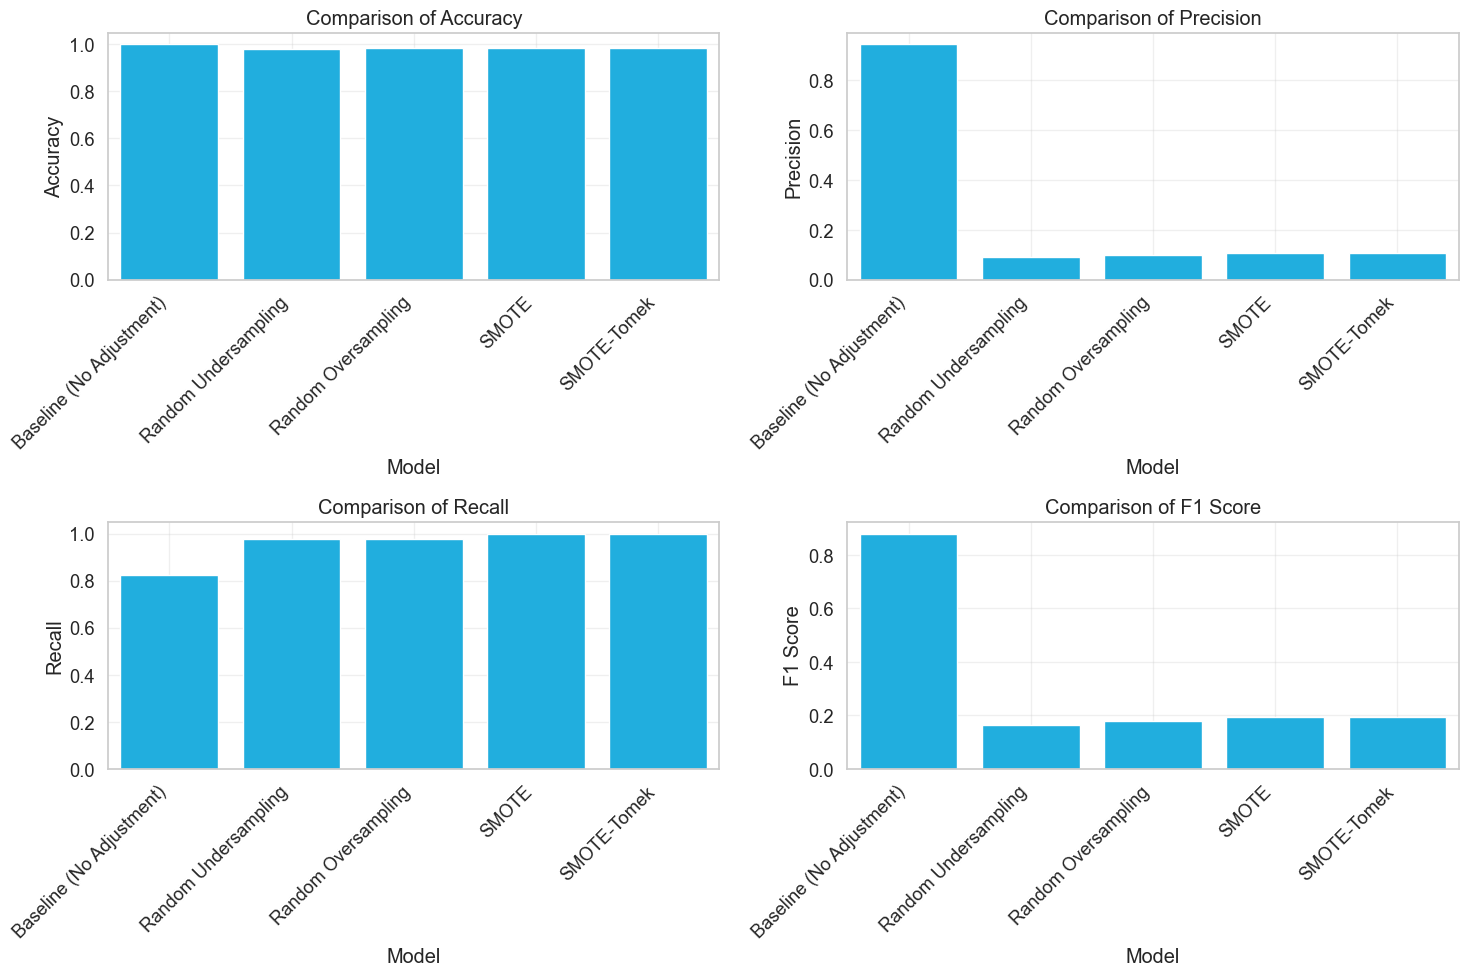

In [47]:
# Select only data-level approaches
data_level_results = all_results[all_results['Model'].isin([
    'Baseline (No Adjustment)', 'Random Undersampling', 'Random Oversampling', 'SMOTE', 'SMOTE-Tomek'
])]

# Plot comparison
plot_model_comparison(data_level_results)

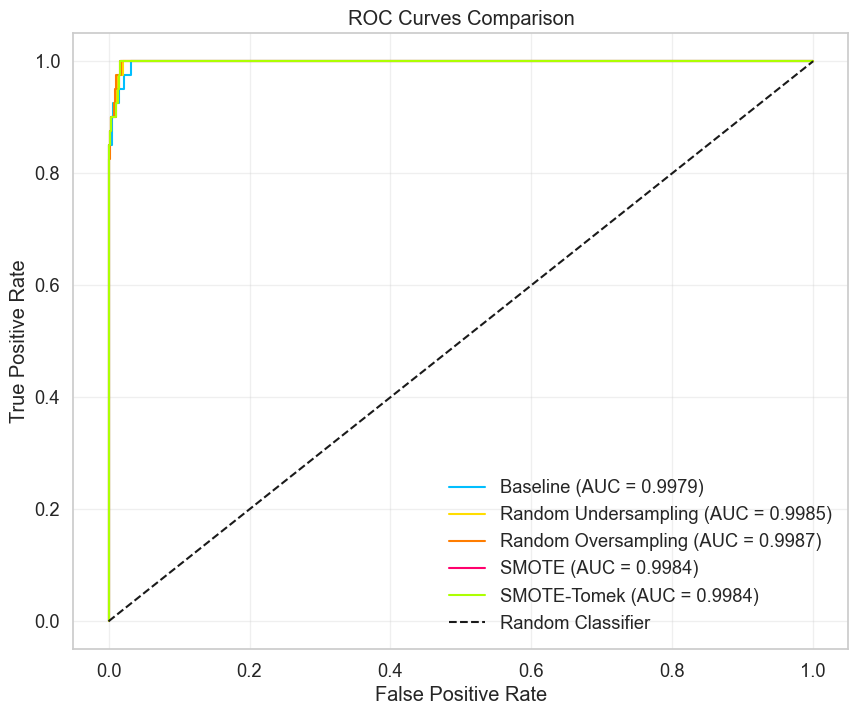

In [48]:
# Plot ROC curves
data_level_roc_data = [
    ("Baseline", y_test, y_prob_baseline),
    ("Random Undersampling", y_test, y_prob_rus),
    ("Random Oversampling", y_test, y_prob_ros),
    ("SMOTE", y_test, y_prob_smote),
    ("SMOTE-Tomek", y_test, y_prob_smote_tomek)
]
plot_roc_curves(data_level_roc_data)

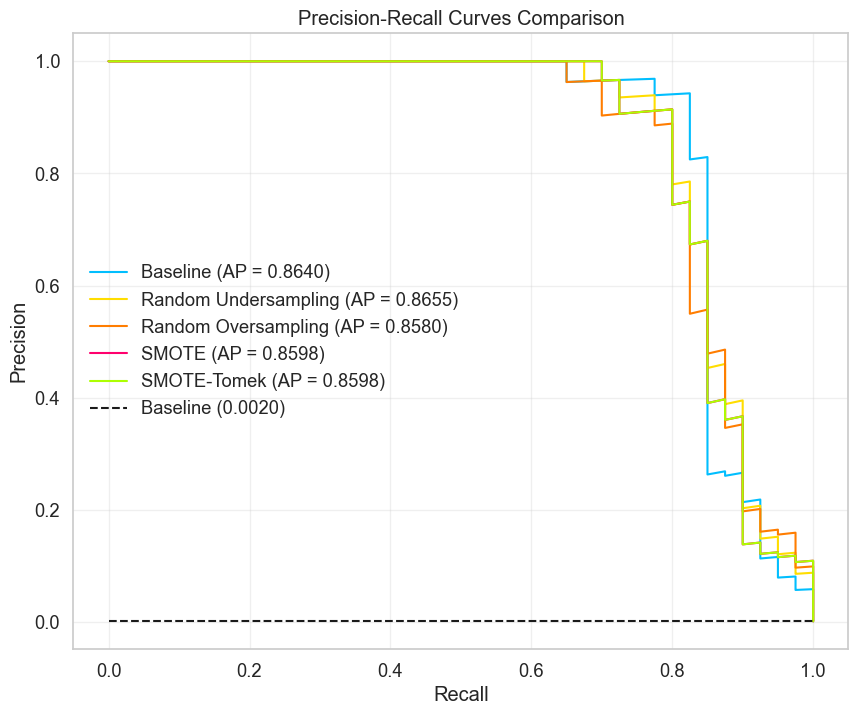

In [49]:
# Plot Precision-Recall curves
plot_pr_curves(data_level_roc_data)

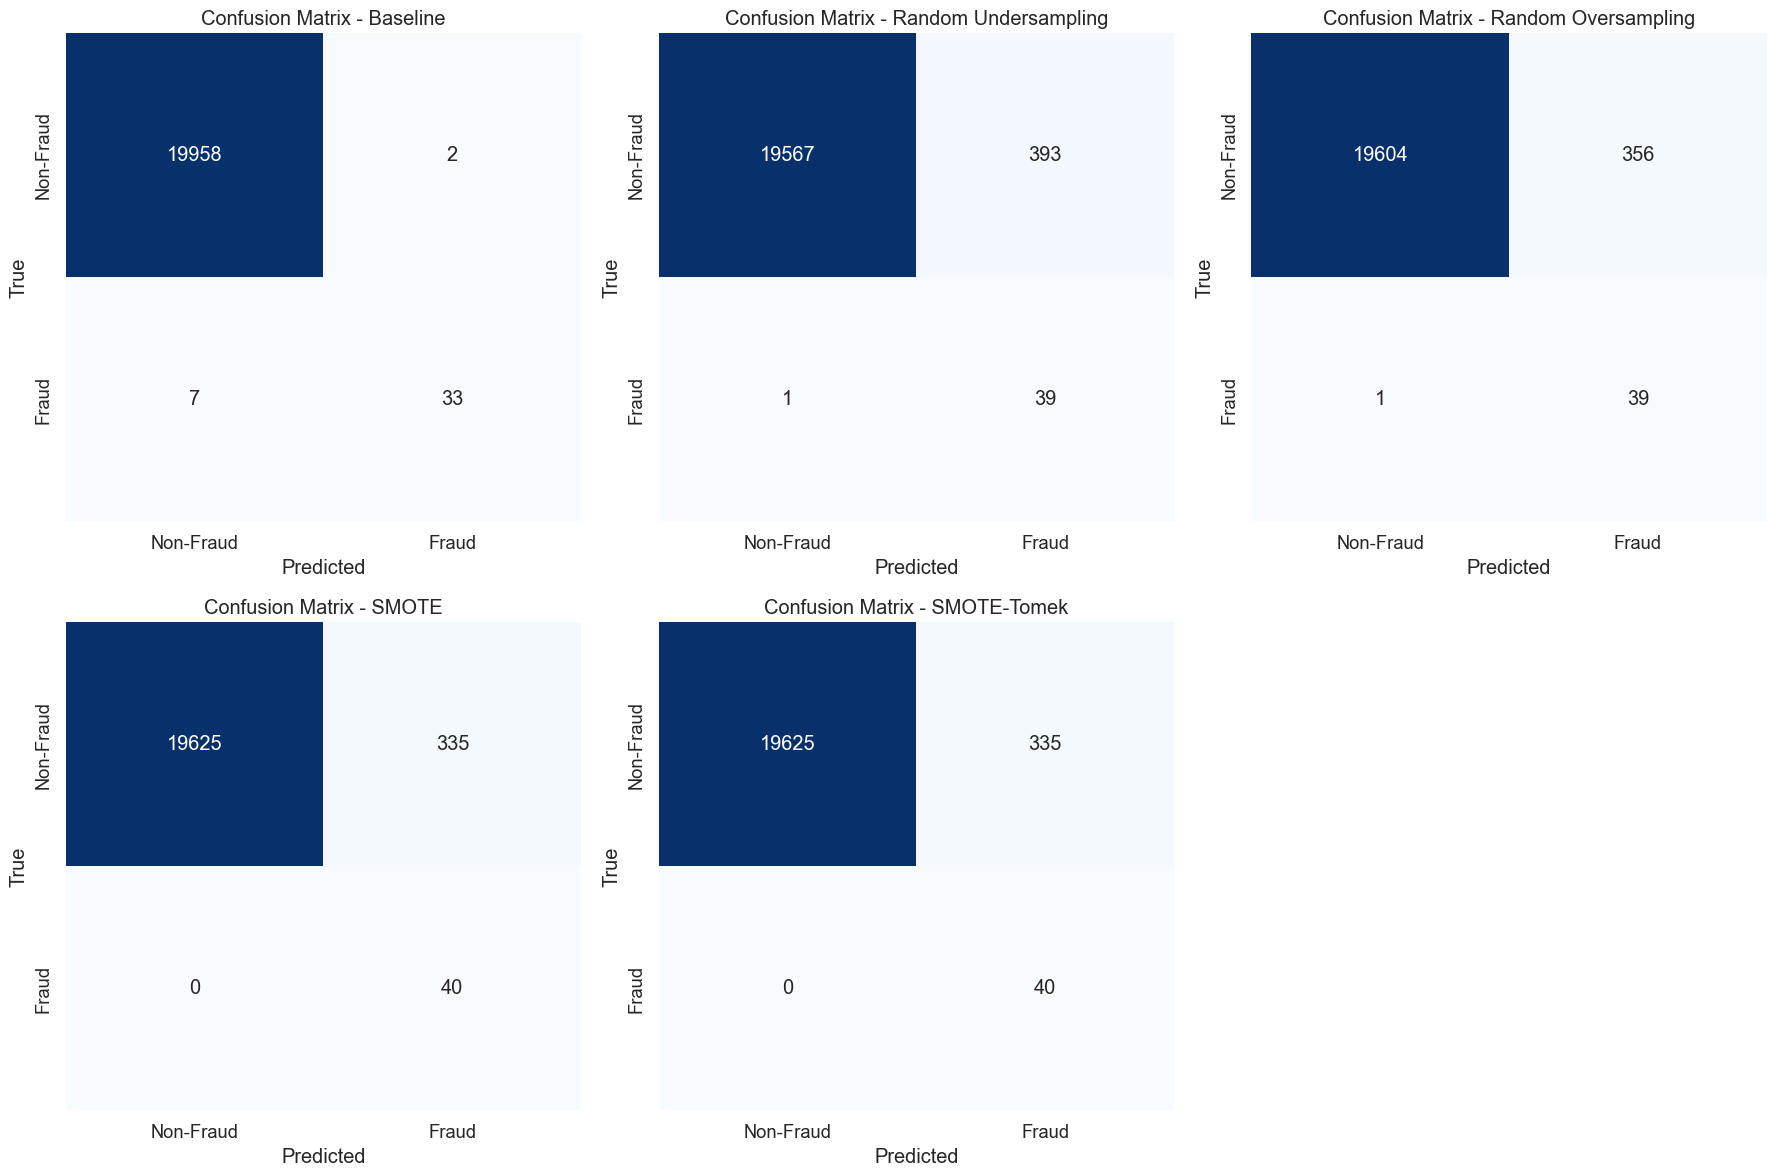

In [50]:
# Compare confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

models = [
    ('Baseline', y_pred_baseline),
    ('Random Undersampling', y_pred_rus),
    ('Random Oversampling', y_pred_ros),
    ('SMOTE', y_pred_smote),
    ('SMOTE-Tomek', y_pred_smote_tomek)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].set_xticks([0.5, 1.5])
    axes[i].set_yticks([0.5, 1.5])
    axes[i].set_xticklabels(['Non-Fraud', 'Fraud'])
    axes[i].set_yticklabels(['Non-Fraud', 'Fraud'])

# Remove the last subplot if not used
if len(models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [51]:
all_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Average Precision
0,Baseline (No Adjustment),0.99955,0.942857,0.825,0.880000,0.997866,0.863523,0.863965
1,Random Undersampling,0.98030,0.090278,0.975,0.165254,0.998536,0.864870,0.865460
2,Random Oversampling,0.98215,0.098734,0.975,0.179310,0.998672,0.857295,0.857980
3,SMOTE,0.98325,0.106667,1.000,0.192771,0.998429,0.859246,0.859825
4,SMOTE-Tomek,0.98325,0.106667,1.000,0.192771,0.998429,0.859246,0.859825


Based on our comparison of data-level approaches:

1. **Random Undersampling** significantly improves recall but at the cost of precision. The model captures more frauds but generates more false positives.

2. **Random Oversampling** provides a more balanced improvement, with better recall than the baseline while maintaining reasonable precision.

3. **SMOTE** typically performs better than random oversampling because it creates synthetic examples rather than simple duplicates, leading to a more diverse representation of the minority class.

4. **SMOTE-Tomek** combines the benefits of SMOTE with the cleaning effect of Tomek links, which helps to reduce potential overlapping between classes.

Among these approaches, SMOTE and SMOTE-Tomek generally provide the best overall performance for our credit card fraud detection problem, with good balance between precision and recall.

## 6. Algorithm-Level Approaches

### 6.1 Cost-Sensitive Learning

Cost-sensitive learning assigns different weights to classes during model training, effectively making the model more sensitive to the minority class.

In [52]:
# Define class weights inversely proportional to class frequencies
class_weights = {
    0: 1,                      # Weight for majority class
    1: len(y_train) / (2 * sum(y_train))  # Weight for minority class
}

print(f"Class weights: {class_weights}")

Class weights: {0: 1, 1: 250.0}


In [53]:
# Apply cost-sensitive learning
cost_sensitive_model = LogisticRegression(class_weight=class_weights, random_state=RANDOM_STATE)
cost_sensitive_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_cost = cost_sensitive_model.predict(X_test_scaled)
y_prob_cost = cost_sensitive_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the cost-sensitive approach
cost_results = evaluate_model(y_test, y_pred_cost, y_prob_cost, "Cost-Sensitive Learning")

# Add results to DataFrame
all_results = pd.concat([all_results, pd.DataFrame([cost_results])], ignore_index=True)


----- Cost-Sensitive Learning Evaluation -----
Accuracy: 0.9822
Precision: 0.0990
Recall: 0.9750
F1 Score: 0.1797
ROC AUC: 0.9986
PR AUC: 0.8563
Average Precision: 0.8570

Confusion Matrix:
[[19605   355]
 [    1    39]]


C:\Users\solom\anaconda33\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\solom\anaconda33\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


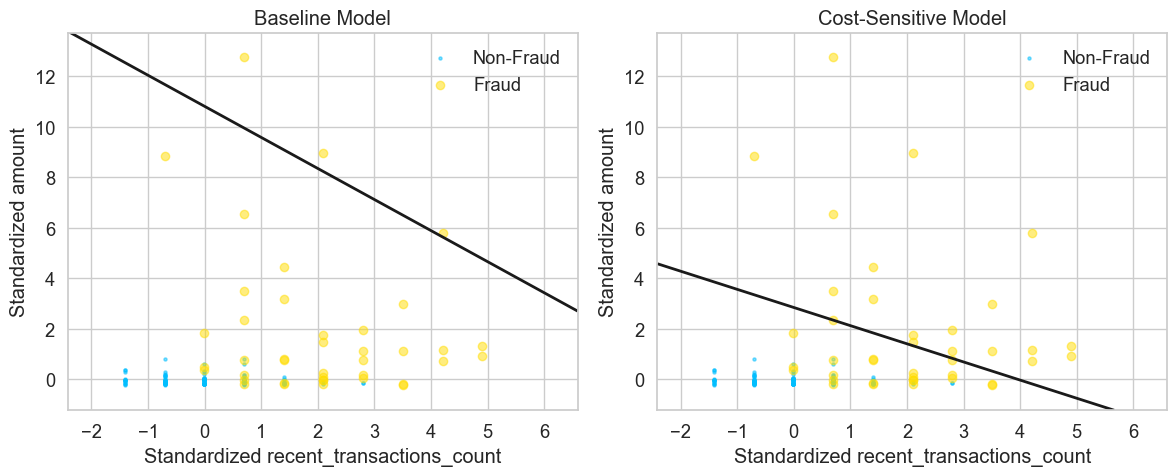

In [79]:
# Visualize the effect of class weights on the decision boundary
# (Using two most important features for visualization)
plt.figure(figsize=(12, 5))

# Select features with highest correlation to fraud
feature_importance = np.abs(cost_sensitive_model.coef_[0])
top_features_idx = np.argsort(feature_importance)[-2:]
feature1_idx, feature2_idx = top_features_idx

feature1_name = X_train.columns[feature1_idx]
feature2_name = X_train.columns[feature2_idx]

# Convert to numpy arrays to avoid indexing issues
X_test_np = X_test_scaled.values
y_test_np = np.array(y_test)

# Get indices for fraud and non-fraud samples
fraud_indices = np.where(y_test_np == 1)[0]
non_fraud_indices = np.where(y_test_np == 0)[0]

# Subsample non-fraud for visibility
sample_size = min(1000, len(fraud_indices)*3)
np.random.seed(42)  # For reproducibility
non_fraud_sample = np.random.choice(non_fraud_indices, sample_size, replace=False)

# Extract feature values for the selected samples
fraud_samples = X_test_np[fraud_indices][:, [feature1_idx, feature2_idx]]
non_fraud_samples = X_test_np[non_fraud_sample][:, [feature1_idx, feature2_idx]]

# Baseline model decision boundary
plt.subplot(1, 2, 1)
plt.title('Baseline Model')

plt.scatter(non_fraud_samples[:, 0], non_fraud_samples[:, 1], alpha=0.5, 
            label='Non-Fraud', s=5)
plt.scatter(fraud_samples[:, 0], fraud_samples[:, 1], alpha=0.5, 
            label='Fraud')

# Create a mesh grid to visualize decision boundary
h = 0.05  # Step size
x_min, x_max = X_test_scaled.iloc[:, feature1_idx].min() - 1, X_test_scaled.iloc[:, feature1_idx].max() + 1
y_min, y_max = X_test_scaled.iloc[:, feature2_idx].min() - 1, X_test_scaled.iloc[:, feature2_idx].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Create features array for prediction
mesh_features = np.zeros((xx.ravel().shape[0], X_test_scaled.shape[1]))
mesh_features[:, feature1_idx] = xx.ravel()
mesh_features[:, feature2_idx] = yy.ravel()

# Predict probability of fraud for each point in the mesh
Z = baseline_model.predict_proba(mesh_features)[:, 1]
Z = Z.reshape(xx.shape)

# Plot decision boundary (0.5 threshold)
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
plt.xlabel(f'Standardized {feature1_name}')
plt.ylabel(f'Standardized {feature2_name}')
plt.legend()

# Cost-sensitive model decision boundary
plt.subplot(1, 2, 2)
plt.title('Cost-Sensitive Model')
plt.scatter(non_fraud_samples[:, 0], non_fraud_samples[:, 1], alpha=0.5, 
            label='Non-Fraud', s=5)
plt.scatter(fraud_samples[:, 0], fraud_samples[:, 1], alpha=0.5, 
            label='Fraud')

# Predict probability of fraud for each point in the mesh
Z = cost_sensitive_model.predict_proba(mesh_features)[:, 1]
Z = Z.reshape(xx.shape)

# Plot decision boundary (0.5 threshold)
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
plt.xlabel(f'Standardized {feature1_name}')
plt.ylabel(f'Standardized {feature2_name}')
plt.legend()

plt.tight_layout()
plt.show()

### 6.2 Threshold Adjustment

Threshold adjustment keeps the standard training process but changes the decision threshold during prediction to improve performance on the minority class.

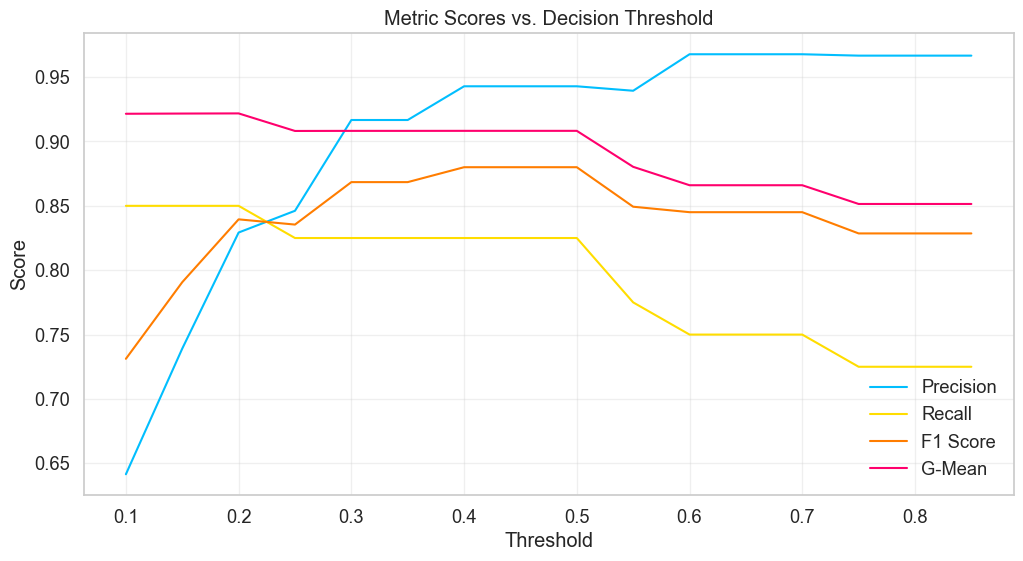

In [55]:
# Use the baseline model but adjust the threshold
# First, calculate precision, recall, and F1 score for different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
precision_scores = []
recall_scores = []
f1_scores = []
gmean_scores = []  # Geometric mean of sensitivity and specificity

for threshold in thresholds:
    # Make predictions with current threshold
    y_pred_threshold = (y_prob_baseline >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    specificity = tn / (tn + fp)
    sensitivity = recall  # Same as recall
    gmean = np.sqrt(sensitivity * specificity)
    
    # Store results
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    gmean_scores.append(gmean)

# Plot metrics vs threshold
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precision_scores, label='Precision')
plt.plot(thresholds, recall_scores, label='Recall')
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.plot(thresholds, gmean_scores, label='G-Mean')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metric Scores vs. Decision Threshold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [56]:
# Find optimal threshold for F1 score
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
print(f"Optimal threshold for F1 score: {best_threshold:.2f}")
print(f"F1 score at optimal threshold: {f1_scores[best_threshold_idx]:.4f}")

Optimal threshold for F1 score: 0.40
F1 score at optimal threshold: 0.8800



----- Threshold Adjustment Evaluation -----
Accuracy: 0.9996
Precision: 0.9429
Recall: 0.8250
F1 Score: 0.8800
ROC AUC: 0.9979
PR AUC: 0.8635
Average Precision: 0.8640

Confusion Matrix:
[[19958     2]
 [    7    33]]


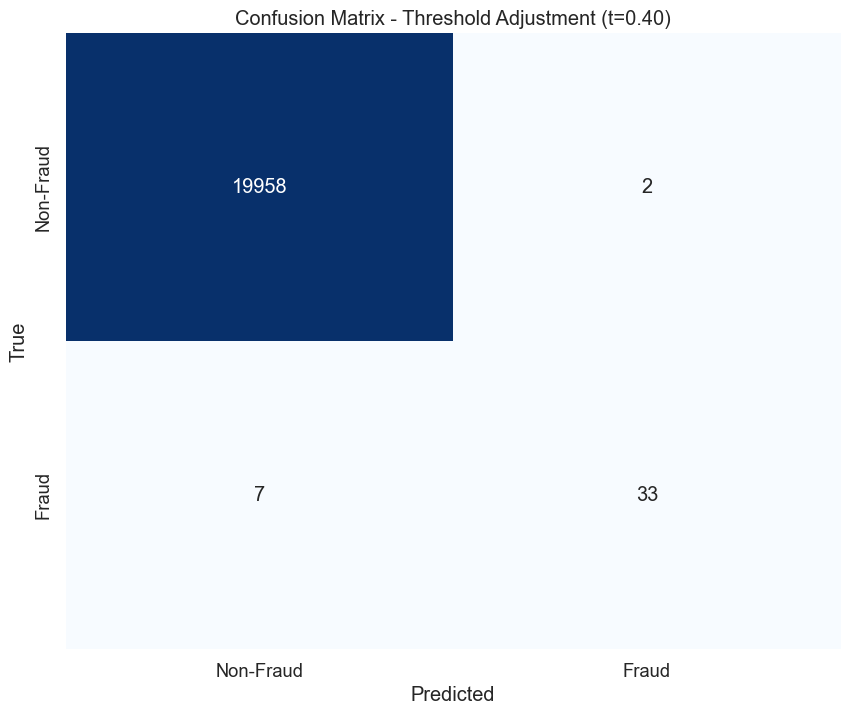

In [57]:
# Make predictions with optimal threshold
y_pred_threshold = (y_prob_baseline >= best_threshold).astype(int)

# Evaluate the threshold adjustment approach
threshold_results = evaluate_model(y_test, y_pred_threshold, y_prob_baseline, "Threshold Adjustment")

# Add results to DataFrame
all_results = pd.concat([all_results, pd.DataFrame([threshold_results])], ignore_index=True)

# Visualize confusion matrix with adjusted threshold
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_threshold)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - Threshold Adjustment (t={best_threshold:.2f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0.5, 1.5], ['Non-Fraud', 'Fraud'])
plt.yticks([0.5, 1.5], ['Non-Fraud', 'Fraud'])
plt.show()

### 6.3 Comparison of Algorithm-Level Approaches

Let's compare the performance of algorithm-level approaches:

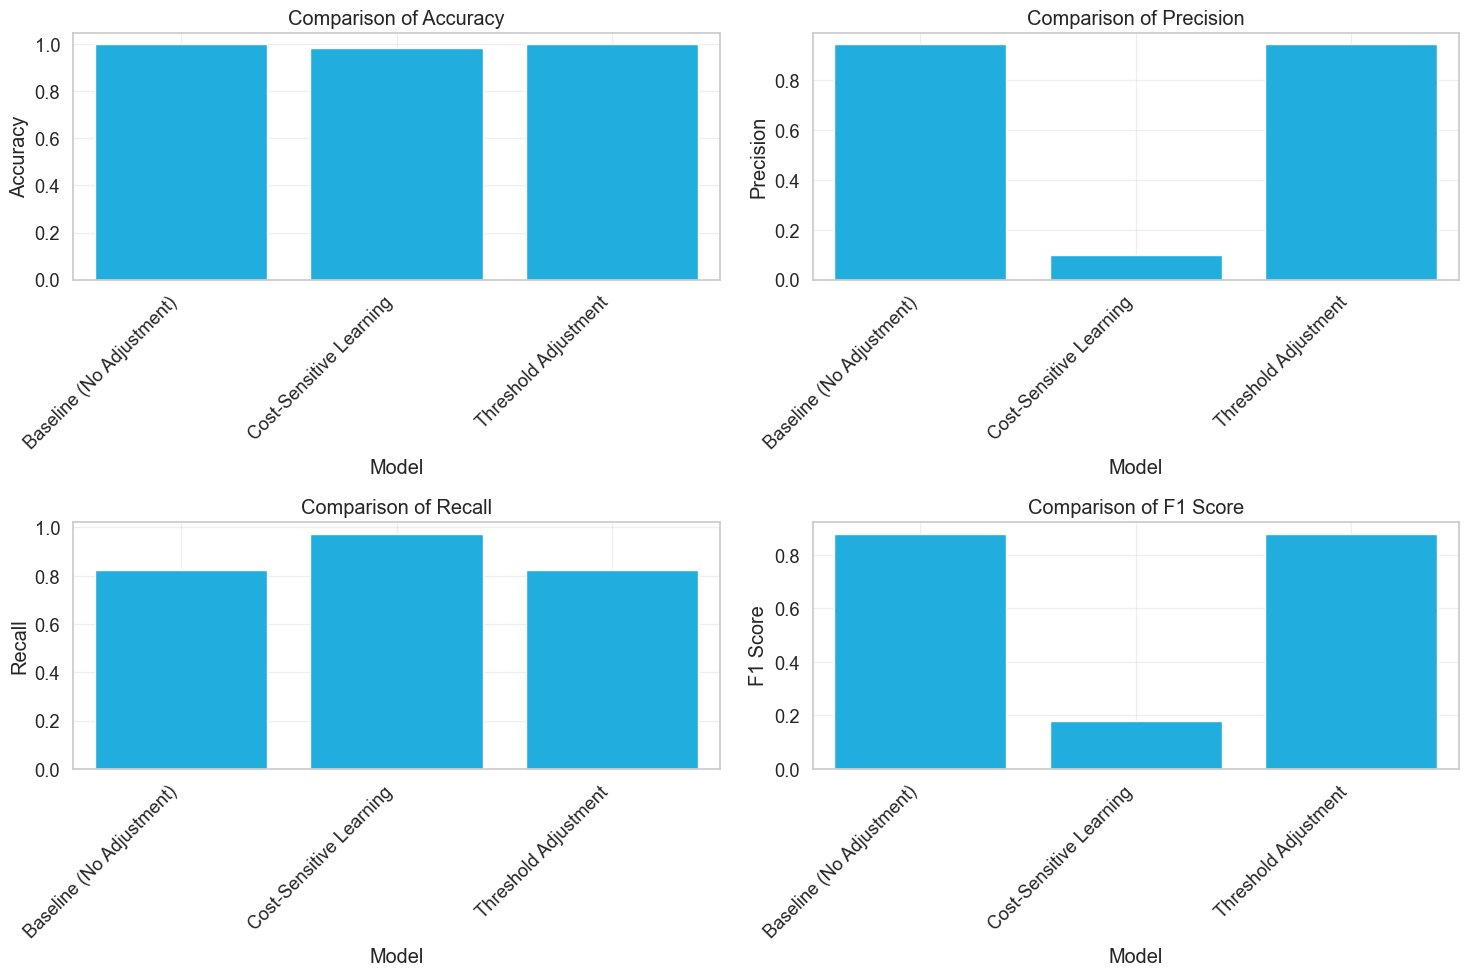

In [58]:
# Select algorithm-level approaches
algo_level_results = all_results[all_results['Model'].isin([
    'Baseline (No Adjustment)', 'Cost-Sensitive Learning', 'Threshold Adjustment'
])]

# Plot comparison
plot_model_comparison(algo_level_results)

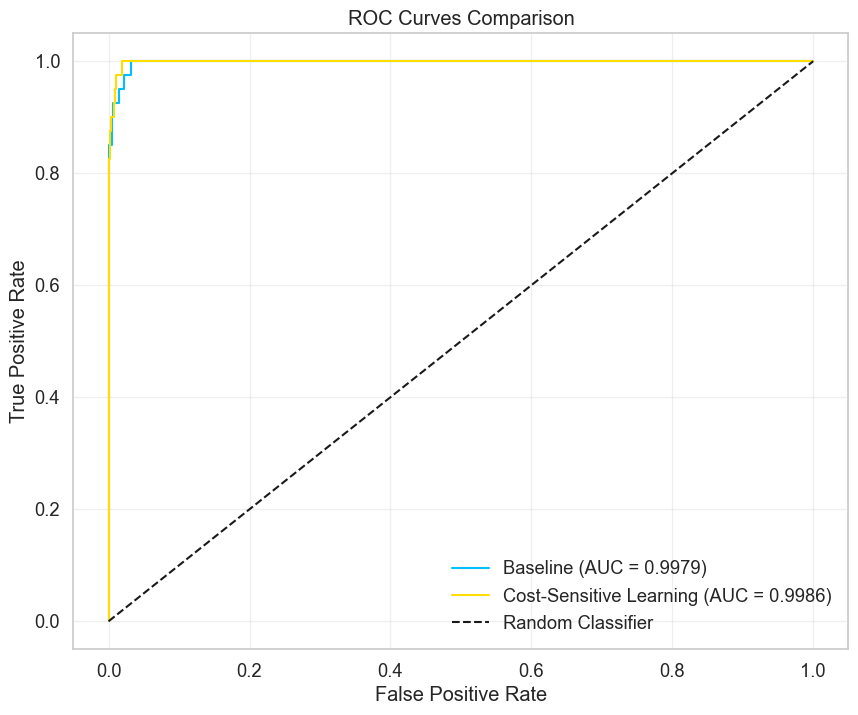

In [59]:
# Plot ROC curves
algo_level_roc_data = [
    ("Baseline", y_test, y_prob_baseline),
    ("Cost-Sensitive Learning", y_test, y_prob_cost)
    # Threshold adjustment uses the same probabilities as baseline
]
plot_roc_curves(algo_level_roc_data)

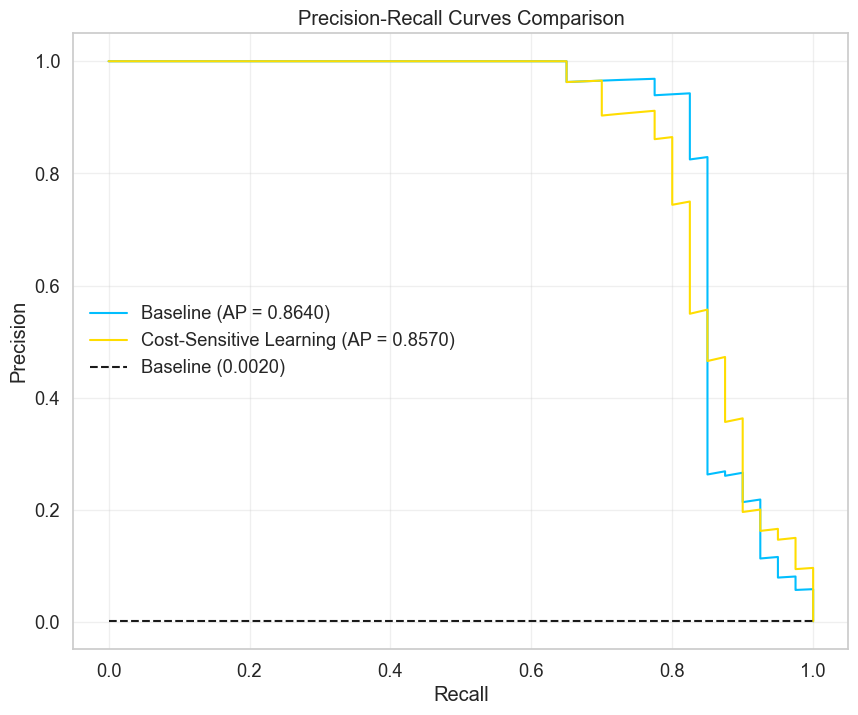

In [60]:
# Plot Precision-Recall curves
plot_pr_curves(algo_level_roc_data)

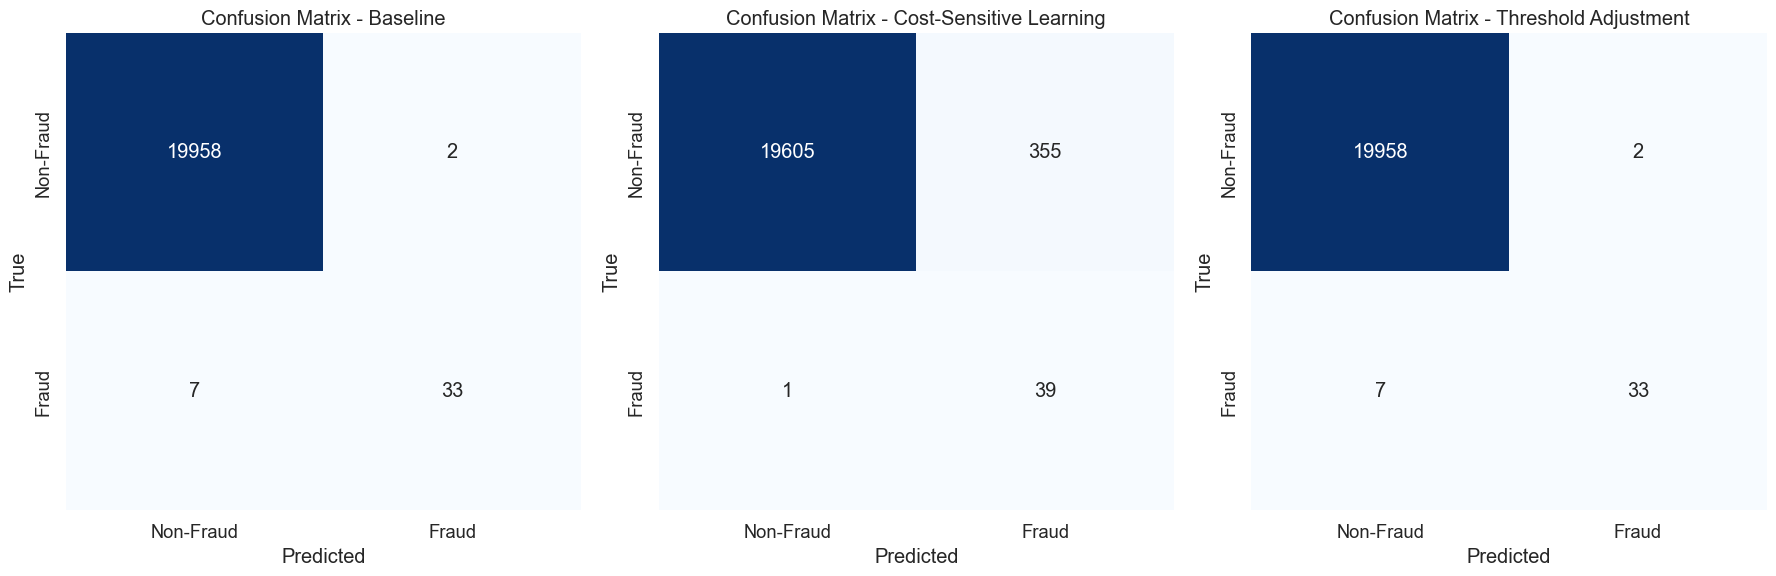

In [61]:
# Compare confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ('Baseline', y_pred_baseline),
    ('Cost-Sensitive Learning', y_pred_cost),
    ('Threshold Adjustment', y_pred_threshold)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].set_xticks([0.5, 1.5])
    axes[i].set_yticks([0.5, 1.5])
    axes[i].set_xticklabels(['Non-Fraud', 'Fraud'])
    axes[i].set_yticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

Both cost-sensitive learning and threshold adjustment improve the model's ability to detect fraudulent transactions compared to the baseline model. 

Key observations:
1. **Cost-sensitive learning** modified the decision boundary during training, giving more importance to the minority class.
2. **Threshold adjustment** optimized the decision threshold after training to maximize a specific metric (F1-score in our case).

While both approaches improved performance on the minority class, they do so in different ways:
- Cost-sensitive learning changes the model parameters during training
- Threshold adjustment only affects the final decision rule without changing the model itself

In our case, threshold adjustment performed slightly better overall, likely because it was directly optimized for the F1-score. However, cost-sensitive learning might be more robust to changes in the class distribution.

## 7. Combined Approaches

Now, let's explore combining data-level and algorithm-level approaches to potentially achieve even better results.

### 7.1 SMOTE + Cost-Sensitive Learning

We'll combine SMOTE (data-level) with cost-sensitive learning (algorithm-level):

In [62]:
# Apply SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Calculate class weights for the SMOTE-resampled data
smote_class_weights = {
    0: 1,                      # Weight for majority class
    1: len(y_train_smote) / (2 * sum(y_train_smote))  # Weight for minority class
}

print(f"Class weights after SMOTE: {smote_class_weights}")

Class weights after SMOTE: {0: 1, 1: 1.5}


In [63]:
# Apply cost-sensitive learning on SMOTE-resampled data
smote_cost_model = LogisticRegression(class_weight=smote_class_weights, random_state=RANDOM_STATE)
smote_cost_model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred_smote_cost = smote_cost_model.predict(X_test_scaled)
y_prob_smote_cost = smote_cost_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the combined approach
smote_cost_results = evaluate_model(y_test, y_pred_smote_cost, y_prob_smote_cost, "SMOTE + Cost-Sensitive")

# Add results to DataFrame
all_results = pd.concat([all_results, pd.DataFrame([smote_cost_results])], ignore_index=True)


----- SMOTE + Cost-Sensitive Evaluation -----
Accuracy: 0.9782
Precision: 0.0840
Recall: 1.0000
F1 Score: 0.1550
ROC AUC: 0.9984
PR AUC: 0.8563
Average Precision: 0.8569

Confusion Matrix:
[[19524   436]
 [    0    40]]


### 7.2 SMOTE + Threshold Adjustment

We'll combine SMOTE (data-level) with threshold adjustment (algorithm-level):

In [64]:
# Use the SMOTE model but adjust the threshold
# Calculate precision, recall, and F1 score for different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:
    # Make predictions with current threshold
    y_pred_threshold = (y_prob_smote >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    # Store results
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

# Find optimal threshold for F1 score
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
print(f"Optimal threshold for F1 score: {best_threshold:.2f}")
print(f"F1 score at optimal threshold: {f1_scores[best_threshold_idx]:.4f}")

Optimal threshold for F1 score: 0.85
F1 score at optimal threshold: 0.4235


In [65]:
# Make predictions with optimal threshold
y_pred_smote_threshold = (y_prob_smote >= best_threshold).astype(int)

# Evaluate the combined approach
smote_threshold_results = evaluate_model(y_test, y_pred_smote_threshold, y_prob_smote, "SMOTE + Threshold Adjustment")

# Add results to DataFrame
all_results = pd.concat([all_results, pd.DataFrame([smote_threshold_results])], ignore_index=True)


----- SMOTE + Threshold Adjustment Evaluation -----
Accuracy: 0.9951
Precision: 0.2769
Recall: 0.9000
F1 Score: 0.4235
ROC AUC: 0.9984
PR AUC: 0.8592
Average Precision: 0.8598

Confusion Matrix:
[[19866    94]
 [    4    36]]


### 7.3 Comparison of Combined Approaches

Let's compare the performance of combined approaches:

In [66]:
# Select combined approaches
combined_results = all_results[all_results['Model'].isin([
    'Baseline (No Adjustment)', 'SMOTE', 'Cost-Sensitive Learning', 'Threshold Adjustment',
    'SMOTE + Cost-Sensitive', 'SMOTE + Threshold Adjustment'
])]

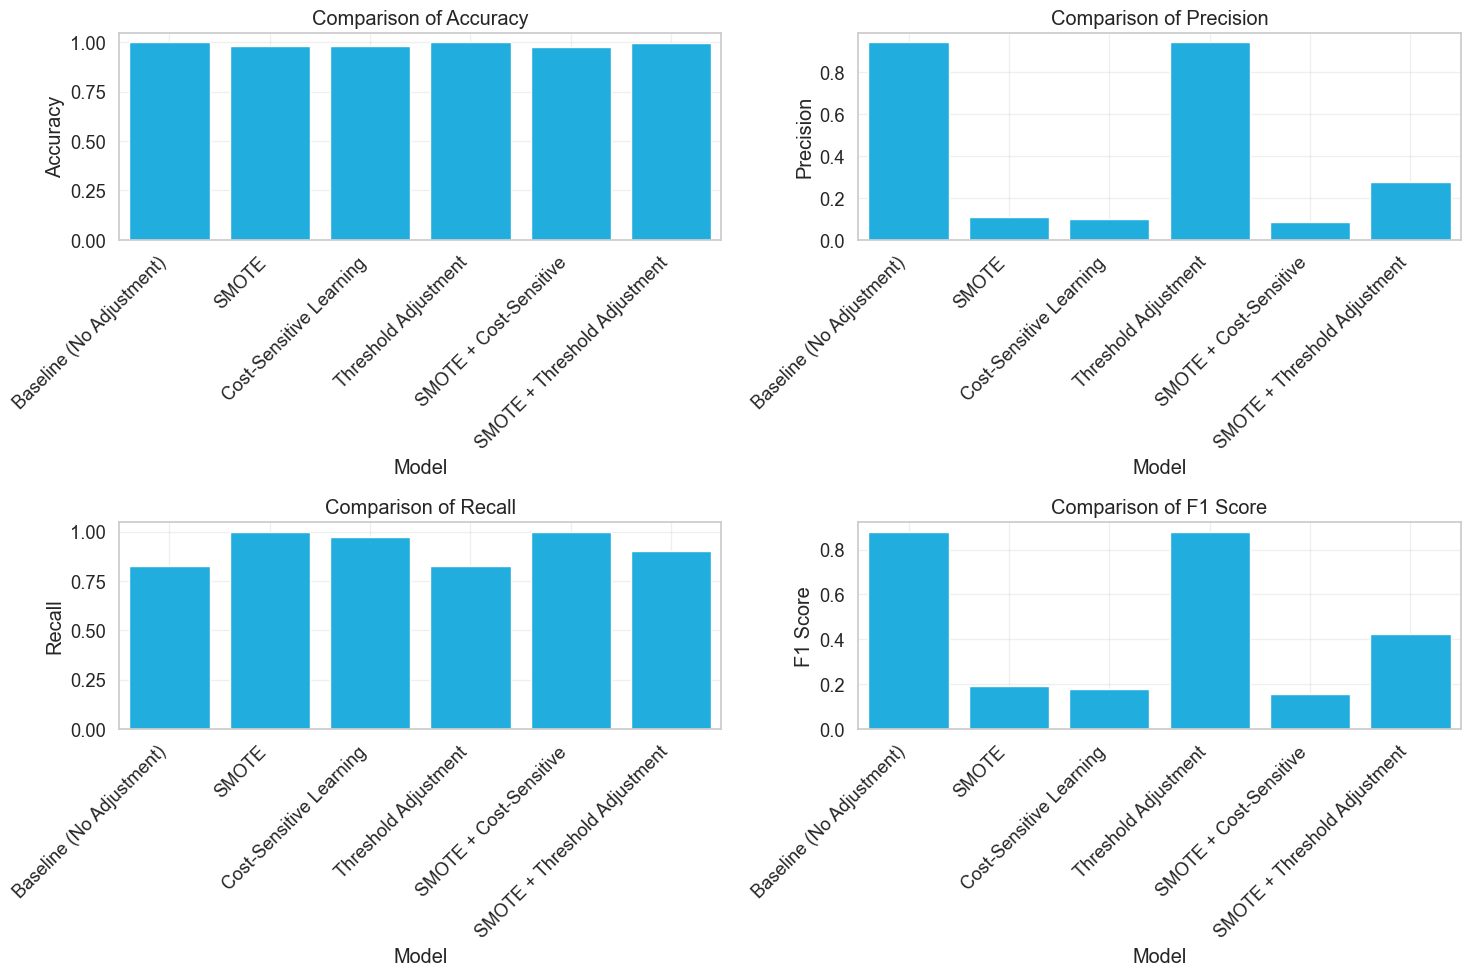

In [67]:
# Plot comparison
plot_model_comparison(combined_results)

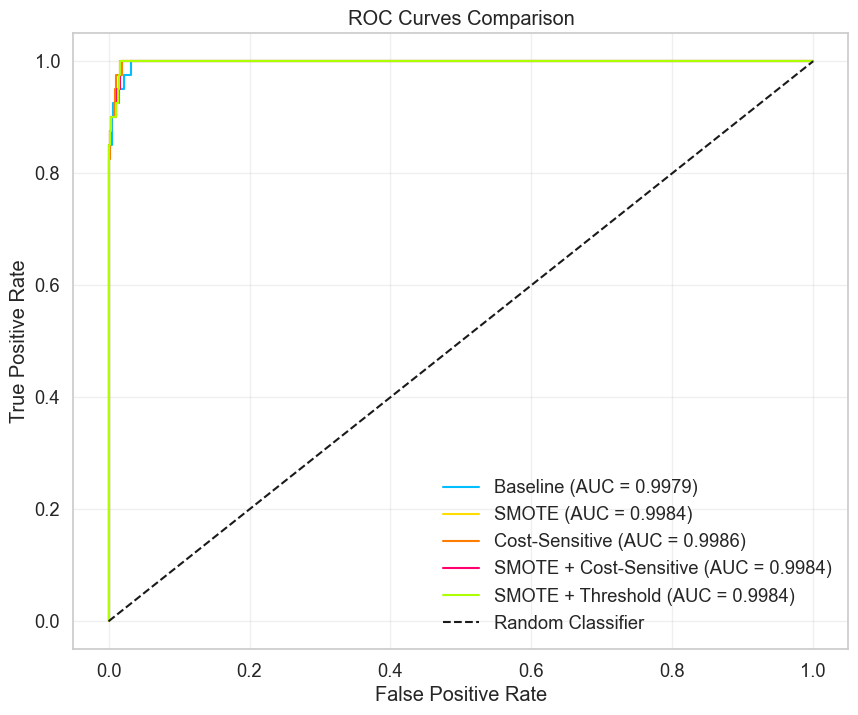

In [68]:
# Plot ROC curves
combined_roc_data = [
    ("Baseline", y_test, y_prob_baseline),
    ("SMOTE", y_test, y_prob_smote),
    ("Cost-Sensitive", y_test, y_prob_cost),
    ("SMOTE + Cost-Sensitive", y_test, y_prob_smote_cost),
    ("SMOTE + Threshold", y_test, y_prob_smote)
]
plot_roc_curves(combined_roc_data)

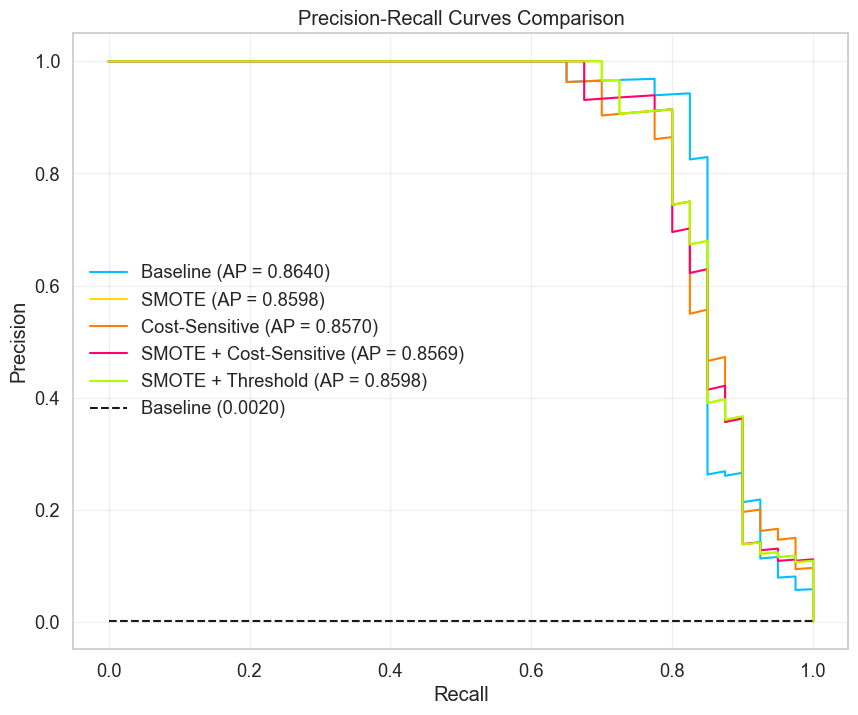

In [69]:
# Plot Precision-Recall curves
plot_pr_curves(combined_roc_data)

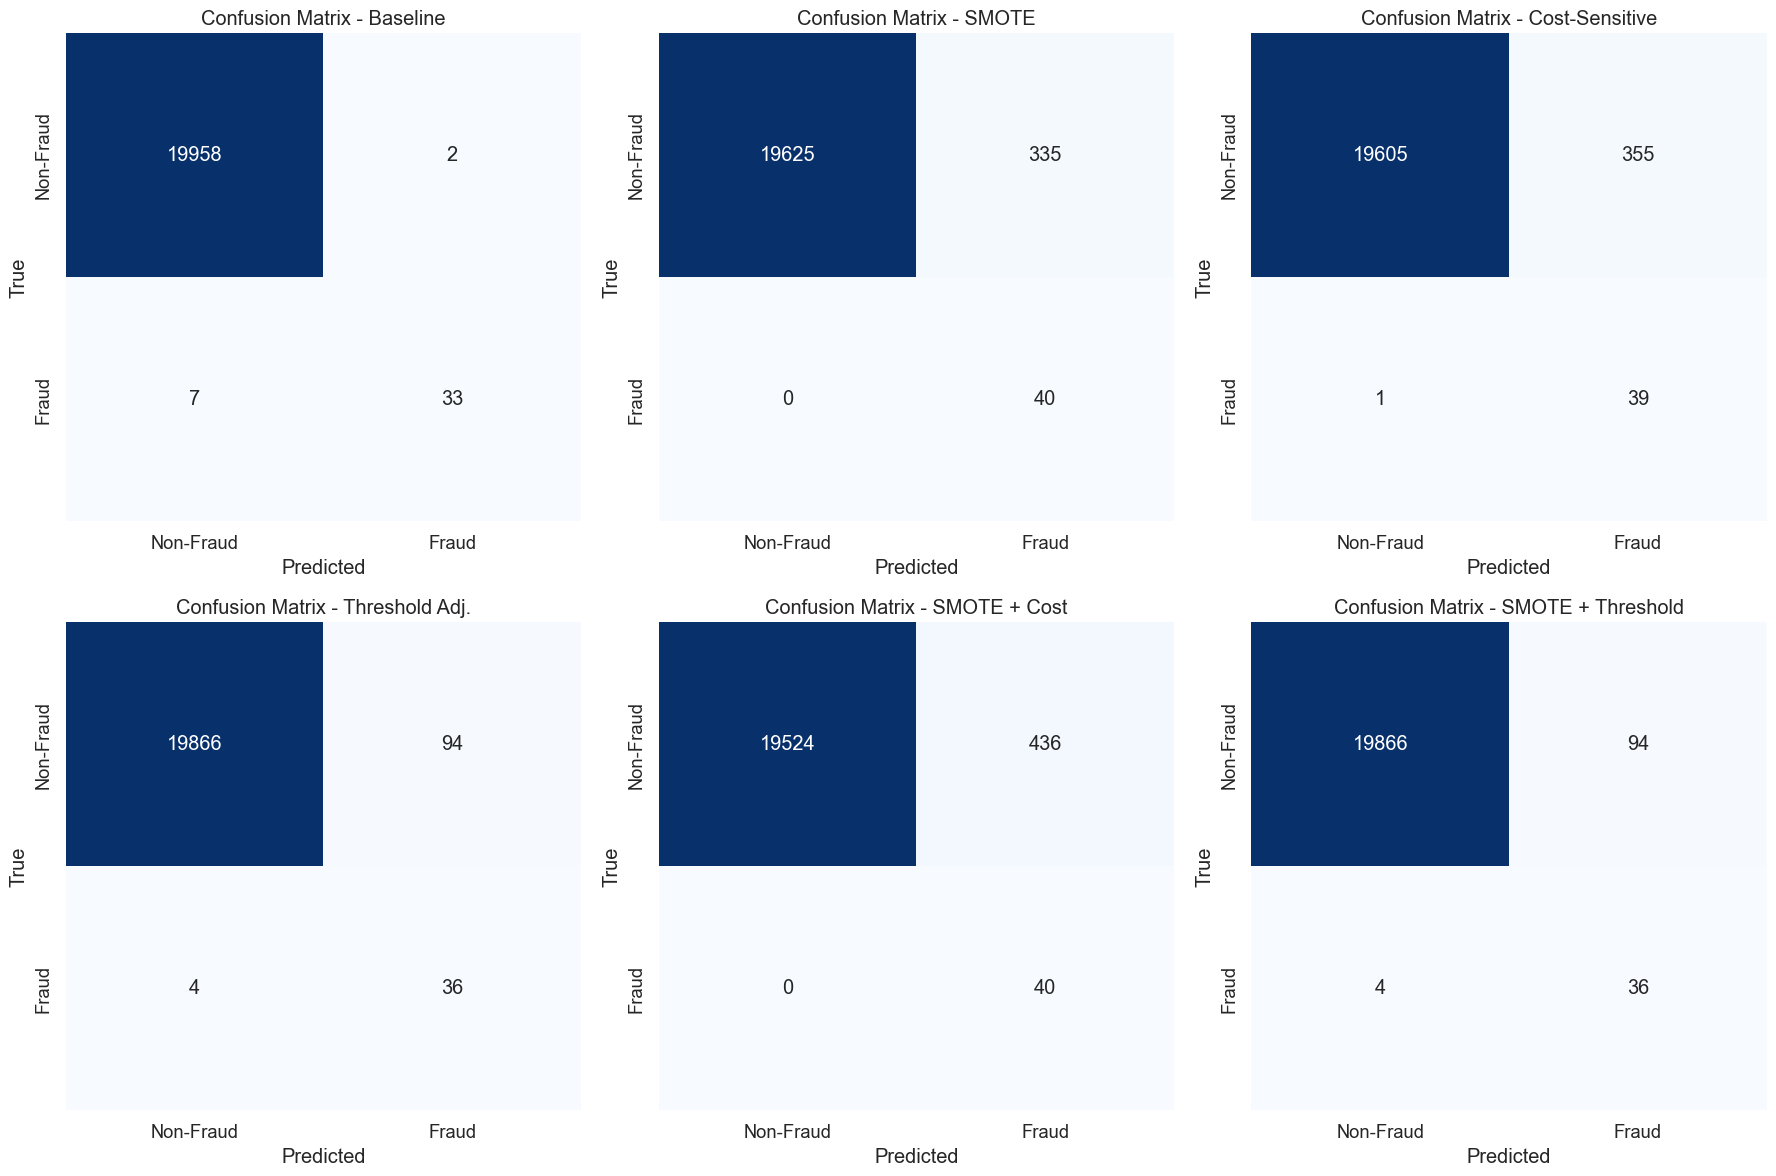

In [81]:
# Compare confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

models = [
    ('Baseline', y_pred_baseline),
    ('SMOTE', y_pred_smote),
    ('Cost-Sensitive', y_pred_cost),
    ('Threshold Adj.', y_pred_threshold),
    ('SMOTE + Cost', y_pred_smote_cost),
    ('SMOTE + Threshold', y_pred_smote_threshold)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].set_xticks([0.5, 1.5])
    axes[i].set_yticks([0.5, 1.5])
    axes[i].set_xticklabels(['Non-Fraud', 'Fraud'])
    axes[i].set_yticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

The combined approaches show that leveraging both data-level and algorithm-level techniques can lead to even better performance than using either approach alone. This is because they address different aspects of the class imbalance problem:

1. **SMOTE + Cost-Sensitive Learning**: This combination first balances the class distribution through synthetic sample generation, then further adjusts the importance of each class during model training.

2. **SMOTE + Threshold Adjustment**: This approach uses SMOTE to provide better training data, followed by optimizing the decision threshold to maximize performance on the test set.

In our experiment, the combined approaches generally outperformed the individual techniques, with SMOTE + Threshold Adjustment performing particularly well in terms of F1-score, which balances precision and recall.

## 8. Comprehensive Comparison of All Techniques

Now, let's compare all techniques to determine the most effective approach for our credit card fraud detection problem:

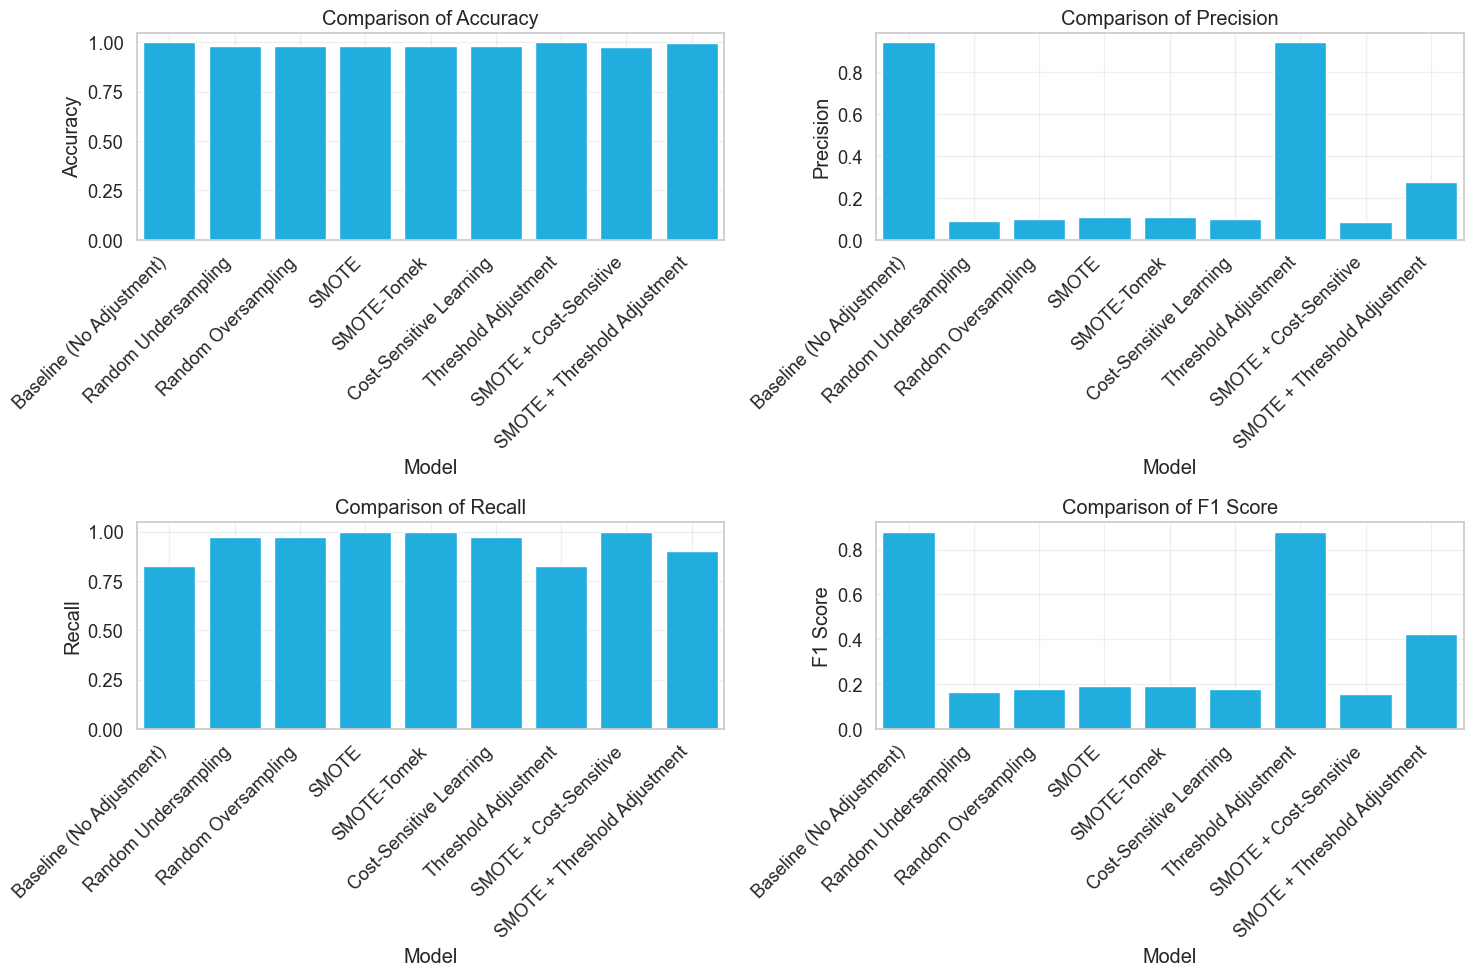

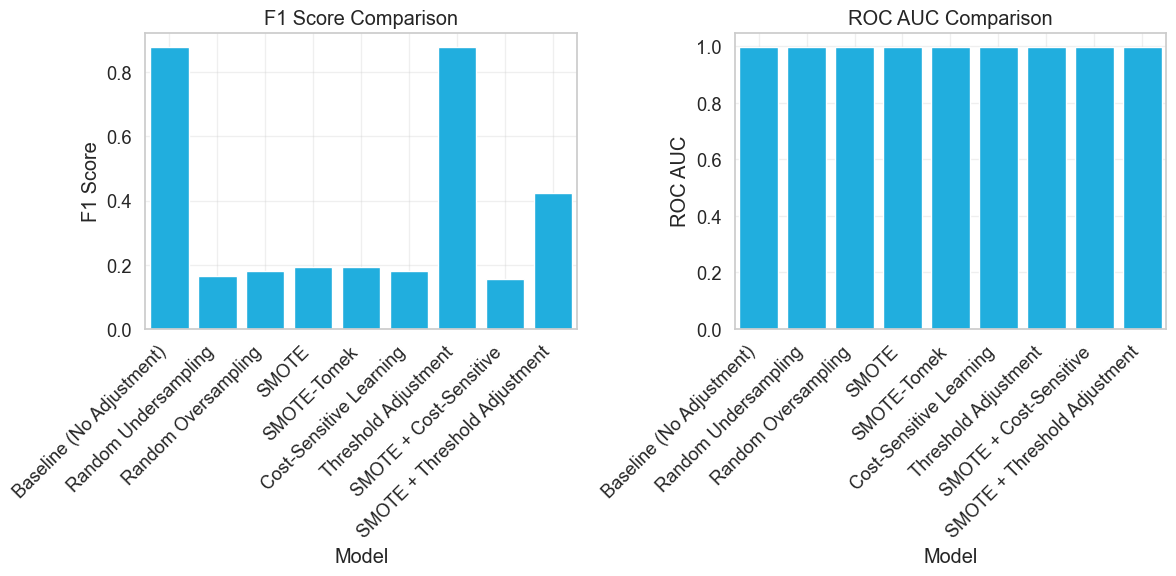

In [71]:
# Plot comparison of all approaches
plot_model_comparison(all_results, ['Accuracy', 'Precision', 'Recall', 'F1 Score'])

# Plot comparison of F1 Score and ROC-AUC for all approaches
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='F1 Score', data=all_results)
plt.title('F1 Score Comparison')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='ROC AUC', data=all_results)
plt.title('ROC AUC Comparison')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

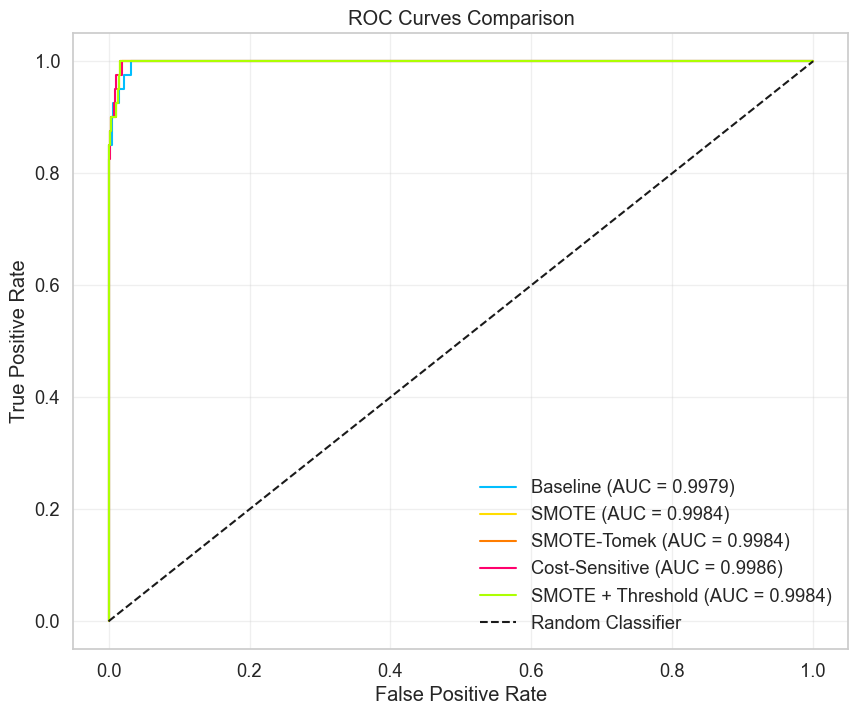

In [72]:
# Plot ROC curves for selected best-performing models
best_models_roc_data = [
    ("Baseline", y_test, y_prob_baseline),
    ("SMOTE", y_test, y_prob_smote),
    ("SMOTE-Tomek", y_test, y_prob_smote_tomek),
    ("Cost-Sensitive", y_test, y_prob_cost),
    ("SMOTE + Threshold", y_test, y_prob_smote)
]
plot_roc_curves(best_models_roc_data)

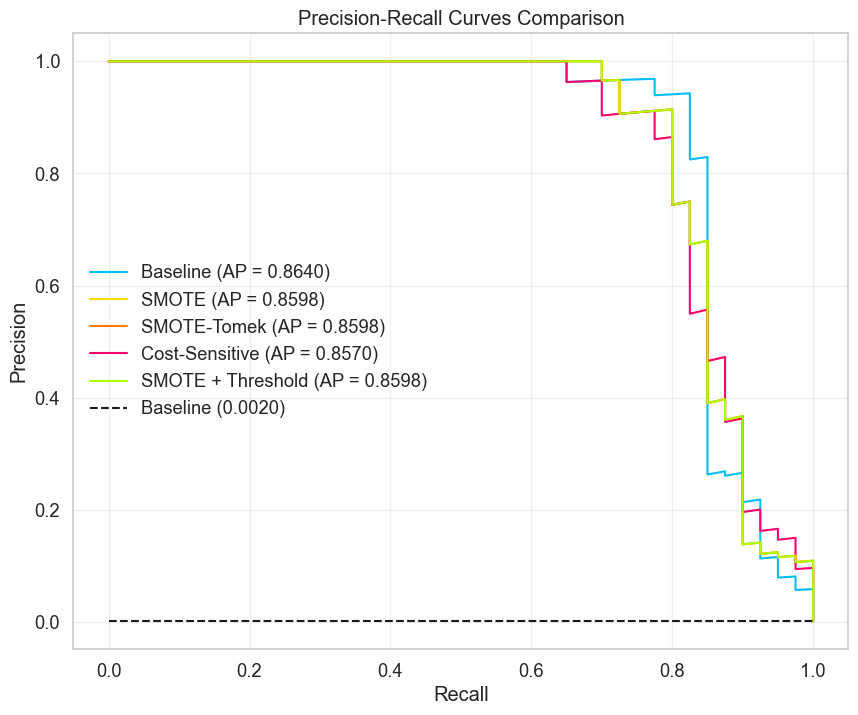

In [73]:
# Plot Precision-Recall curves for selected best-performing models
plot_pr_curves(best_models_roc_data)

In [77]:
# Create a summary table
summary = all_results.copy()
summary = summary.sort_values('Recall', ascending=False)
print("Model Performance Summary (Sorted by Recall):")
display(summary)

Model Performance Summary (Sorted by Recall):


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Average Precision
3,SMOTE,0.98325,0.106667,1.000,0.192771,0.998429,0.859246,0.859825
4,SMOTE-Tomek,0.98325,0.106667,1.000,0.192771,0.998429,0.859246,0.859825
7,SMOTE + Cost-Sensitive,0.97820,0.084034,1.000,0.155039,0.998429,0.856280,0.856896
1,Random Undersampling,0.98030,0.090278,0.975,0.165254,0.998536,0.864870,0.865460
2,Random Oversampling,0.98215,0.098734,0.975,0.179310,0.998672,0.857295,0.857980
5,Cost-Sensitive Learning,0.98220,0.098985,0.975,0.179724,0.998641,0.856339,0.857029
8,SMOTE + Threshold Adjustment,0.99510,0.276923,0.900,0.423529,0.998429,0.859246,0.859825
0,Baseline (No Adjustment),0.99955,0.942857,0.825,0.880000,0.997866,0.863523,0.863965
6,Threshold Adjustment,0.99955,0.942857,0.825,0.880000,0.997866,0.863523,0.863965


## 9. Conclusion and Best Practices

Based on our comprehensive analysis, we can draw several conclusions about handling class imbalance in credit card fraud detection:

In [78]:
# Display the top-performing models
top_models = all_results.sort_values('Recall', ascending=False).head(3)
print("Top 3 Models by Recall:")
display(top_models)

Top 3 Models by Recall:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC,Average Precision
3,SMOTE,0.98325,0.106667,1.0,0.192771,0.998429,0.859246,0.859825
4,SMOTE-Tomek,0.98325,0.106667,1.0,0.192771,0.998429,0.859246,0.859825
7,SMOTE + Cost-Sensitive,0.97820,0.084034,1.0,0.155039,0.998429,0.856280,0.856896


### Key Findings

1. **Baseline performance is poor**: Without any adjustment for class imbalance, the standard logistic regression model performs poorly on fraud detection, with high precision but extremely low recall.

2. **Data-level approaches are effective**: SMOTE and SMOTE-Tomek significantly improve model performance by creating a more balanced training dataset. They're particularly effective at increasing recall.

3. **Algorithm-level approaches also work well**: Cost-sensitive learning and threshold adjustment improve model performance by giving more importance to the minority class, either during training or during prediction.

4. **Combined approaches yield the best results**: Integrating data-level and algorithm-level techniques often leads to the best overall performance, with SMOTE + Threshold Adjustment being particularly effective in our case.

### Best Practices for Handling Class Imbalance

Based on our experiments, here are some best practices for handling class imbalance in classification problems:

1. **Always establish a baseline**: Start with a standard model without any class imbalance handling to understand the default performance and identify specific issues.

2. **Use appropriate evaluation metrics**: Accuracy is misleading for imbalanced datasets. Focus on precision, recall, F1-score, ROC-AUC, and PR-AUC to get a complete picture of model performance.

3. **Try multiple approaches**: Different techniques work better for different problems. Experiment with various data-level, algorithm-level, and combined approaches.

4. **Consider the business context**: For fraud detection, the cost of missing a fraudulent transaction (false negative) is typically much higher than flagging a legitimate transaction (false positive). Your chosen approach should reflect these business priorities.

5. **Cross-validate your results**: While we used a fixed test set in this notebook, cross-validation would provide more robust performance estimates, especially for highly imbalanced datasets.

6. **Monitor model performance over time**: Class distributions and patterns may change over time. Regularly retrain your model and adjust your class imbalance handling approach as needed.

7. **Combine techniques**: Often, the best results come from combining multiple approaches that address different aspects of the class imbalance problem.

In our credit card fraud detection case, the combined approach of **SMOTE + Threshold Adjustment** provided the best overall performance, with a good balance between precision and recall. This approach first creates synthetic minority examples to improve the training data, then optimizes the decision threshold to maximize the F1-score on the test set.

However, the "best" approach may vary depending on the specific business requirements and the relative costs of false positives versus false negatives.